# INSTALLATIONS AND IMPORTS

In [ ]:
!pip install -q xgboost imbalanced-learn shap lime

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef
)
from sklearn.base import clone

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

import xgboost as xgb

warnings.filterwarnings("ignore")

print("🏥 REVISED MONKEYPOX DETECTION SYSTEM")
print("PCA + XGBoost + Training-only Random Oversampling + Threshold Tuning")
print("=" * 75)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
🏥 REVISED MONKEYPOX DETECTION SYSTEM
PCA + XGBoost + Training-only Random Oversampling + Threshold Tuning


# CONFIGURATION

In [ ]:
DATA_PATH = "Data.xls"
RANDOM_STATE = 42
TEST_SIZE = 0.20
PCA_VARIANCE = 0.95

# Clinical target convention (source dataset):
# Dataset Status=1 -> Monkeypox Positive -> clinical y=1
# Dataset Status=0 -> Monkeypox Negative -> clinical y=0
MONKEYPOX_STATUS_VALUE = 1
NEGATIVE_STATUS_VALUE = 0

# Sensitivity-oriented operating point.
# Threshold will be selected from TRAINING-ONLY out-of-fold predictions.
TARGET_SENSITIVITY = 0.90

# Repeated CV for model-performance estimation
CV_FOLDS = 5
CV_REPEATS = 10

# Bootstrap repetitions for final independent test-set uncertainty
N_BOOTSTRAP = 2000

print("Configuration loaded.")
print(f"Data path                 : {DATA_PATH}")
print(f"Test size                 : {TEST_SIZE}")
print(f"PCA variance              : {PCA_VARIANCE:.0%}")
print(f"Monkeypox Status value    : {MONKEYPOX_STATUS_VALUE}")
print(f"Negative Status value     : {NEGATIVE_STATUS_VALUE}")
print(f"Target sensitivity        : {TARGET_SENSITIVITY:.0%}")

Configuration loaded.
Data path                 : Data.xls
Test size                 : 0.2
PCA variance              : 95%
Monkeypox Status value    : 1
Negative Status value     : 0
Target sensitivity        : 90%


# LOAD DATA AND INSPECT DATASET

In [ ]:
print("\n📊 STEP 1: DATA LOADING")
print("-" * 55)

df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded successfully")
print(f"Dataset shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nRaw Status distribution:")
print(df["Status"].value_counts().sort_index())

print("\nRaw Status proportions:")
print((df["Status"].value_counts(normalize=True).sort_index() * 100).round(2))


📊 STEP 1: DATA LOADING
-------------------------------------------------------
✅ Dataset loaded successfully
Dataset shape: (211, 48)

Columns:
['ID', 'rash', 'skin lesions', 'headache', 'ulcerative lesions', 'oral and genital ulcers', 'fever', 'perianal papules', 'inguinal adenopathy', 'genital ulcer lesions', 'pustules', 'cough', 'blisters', 'erythema with vesicles and papules', 'difficulty breathing', 'severe anemia', 'fatigue', 'muscle pain', 'dysphagia', 'decreased physical strength', 'outbreak on the skin', 'hands', 'chest', 'chills', 'general weakness', 'general discomfort', 'adenomegaly', 'myalgia', 'itch', 'papules', 'swollen lymph nodes', 'mild symptoms', 'sore throat', 'malaise', 'asthenia', 'characteristic symptoms of Monkeypox', 'diarrhea', 'Pain urinating', 'ulcers', 'loss of appetite', 'Vesicles', 'lymphadenopathy', 'myalgias', 'postules', 'encephalitis', 'symptoms compatible with monkeypox', 'blisters on limbs and genitals', 'Status']

Raw Status distribution:
Status
0

# VERIFY LABEL SEMANTICS AND CONSTRUCT CLINICAL TARGET

In [ ]:
print("\n🎯 STEP 1.1: CLINICAL LABEL MAPPING")
print("-" * 55)

if not set(df["Status"].dropna().unique()).issubset({0, 1}):
    raise ValueError("Status must contain only 0 and 1.")

raw_positive_count = int((df["Status"] == MONKEYPOX_STATUS_VALUE).sum())
raw_negative_count = int((df["Status"] == NEGATIVE_STATUS_VALUE).sum())

print(f"Rows with Status={MONKEYPOX_STATUS_VALUE}: {raw_positive_count}")
print(f"Rows with Status={NEGATIVE_STATUS_VALUE}: {raw_negative_count}")

y = df["Status"].astype(int)

print("\nClinical class distribution:")
print(y.value_counts().sort_index())

clinical_positive = int((y == 1).sum())
clinical_negative = int((y == 0).sum())

print(f"\nMonkeypox Positive (clinical y=1): {clinical_positive}")
print(f"Monkeypox Negative (clinical y=0): {clinical_negative}")

if clinical_positive != 186 or clinical_negative != 25:
    raise ValueError(
        "Clinical labels do not match the verified source dataset: expected 186 "
        "Monkeypox-positive and 25 negative observations (Status=1 positive, Status=0 negative)."
    )

print("\n✅ Verified: Status=1 is Monkeypox positive and Status=0 is Monkeypox negative.")


🎯 STEP 1.1: CLINICAL LABEL MAPPING
-------------------------------------------------------
Rows with Status=1: 186
Rows with Status=0: 25

Clinical class distribution:
Status
0     25
1    186
Name: count, dtype: int64

Monkeypox Positive (clinical y=1): 186
Monkeypox Negative (clinical y=0): 25

✅ Verified: Status=1 is Monkeypox positive and Status=0 is Monkeypox negative.


# SEPARATE PREDICTORS AND TARGET

In [ ]:
X = df.drop(columns=["ID", "Status"]).copy()

print("\n📋 FEATURE INFORMATION")
print("-" * 55)
print(f"Total CSV columns        : {df.shape[1]}")
print(f"ID column                : 1")
print(f"Predictor features       : {X.shape[1]}")
print(f"Target column            : 1")

print("\nTarget distribution:")
print(y.value_counts().rename(index={0: "Negative", 1: "Positive"}))

print("\nTop 10 symptom frequencies:")
print(X.sum().sort_values(ascending=False).head(10).to_string())


📋 FEATURE INFORMATION
-------------------------------------------------------
Total CSV columns        : 48
ID column                : 1
Predictor features       : 46
Target column            : 1

Target distribution:
Status
Positive    186
Negative     25
Name: count, dtype: int64

Top 10 symptom frequencies:
fever                      80
rash                       58
skin lesions               50
genital ulcer lesions      30
oral and genital ulcers    22
headache                   22
ulcerative lesions         21
muscle pain                14
fatigue                    13
swollen lymph nodes        10


# DATA QUALITY CHECK

In [ ]:
print("\n🔧 STEP 1.2: DATA QUALITY CHECK")
print("-" * 55)

duplicate_count = int(df.duplicated().sum())
missing_total = int(X.isnull().sum().sum())
invalid_target_count = int((~df["Status"].isin([0, 1])).sum())

print(f"Duplicate full rows      : {duplicate_count}")
print(f"Missing feature values   : {missing_total}")
print(f"Invalid Status values    : {invalid_target_count}")

non_binary_columns = []
for column in X.columns:
    vals = set(X[column].dropna().unique())
    if not vals.issubset({0, 1}):
        non_binary_columns.append(column)

print(f"Non-binary symptom cols  : {len(non_binary_columns)}")
if non_binary_columns:
    print(non_binary_columns)
else:
    print("✅ All predictor columns are binary 0/1 symptom indicators.")

print("\nNOTE: The 211-row CSV is treated as the already-screened analytical dataset. "
      "No observations are removed here so the reported sample size remains reproducible.")


🔧 STEP 1.2: DATA QUALITY CHECK
-------------------------------------------------------
Duplicate full rows      : 0
Missing feature values   : 0
Invalid Status values    : 0
Non-binary symptom cols  : 0
✅ All predictor columns are binary 0/1 symptom indicators.

NOTE: The 211-row CSV is treated as the already-screened analytical dataset. No observations are removed here so the reported sample size remains reproducible.


# STRATIFIED TRAIN-TEST SPLIT — BEFORE ANY FITTING

In [ ]:
print("\n✂️ STEP 2: STRATIFIED TRAIN-TEST SPLIT")
print("-" * 55)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training samples         : {len(X_train_raw)}")
print(f"Testing samples          : {len(X_test_raw)}")

print("\nTraining distribution:")
print(y_train.value_counts().sort_index().rename(index={0: "Negative", 1: "Positive"}))

print("\nTesting distribution:")
print(y_test.value_counts().sort_index().rename(index={0: "Negative", 1: "Positive"}))

print(f"\nTraining positive rate: {y_train.mean() * 100:.2f}%")
print(f"Testing positive rate : {y_test.mean() * 100:.2f}%")


✂️ STEP 2: STRATIFIED TRAIN-TEST SPLIT
-------------------------------------------------------
Training samples         : 168
Testing samples          : 43

Training distribution:
Status
Negative     20
Positive    148
Name: count, dtype: int64

Testing distribution:
Status
Negative     5
Positive    38
Name: count, dtype: int64

Training positive rate: 88.10%
Testing positive rate : 88.37%


# LEAKAGE-SAFE PREPROCESSING — TRAINING DATA ONLY

In [ ]:
print("\n🔧 STEP 3: TRAINING-ONLY PREPROCESSING")
print("-" * 55)

imputer = SimpleImputer(strategy="most_frequent")
X_train_imputed = imputer.fit_transform(X_train_raw)
X_test_imputed = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("✅ Imputer fitted only on training data")
print("✅ Scaler fitted only on training data")


🔧 STEP 3: TRAINING-ONLY PREPROCESSING
-------------------------------------------------------
✅ Imputer fitted only on training data
✅ Scaler fitted only on training data


# PCA — FIT ONLY ON TRAINING DATA

In [ ]:
print("\n🔬 STEP 4: PCA DIMENSIONALITY REDUCTION")
print("-" * 55)

pca = PCA(
    n_components=PCA_VARIANCE,
    random_state=RANDOM_STATE
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

explained_variance = float(pca.explained_variance_ratio_.sum())

print("✅ PCA fitted only on training data")
print(f"Original predictors      : {X_train_scaled.shape[1]}")
print(f"PCA components           : {X_train_pca.shape[1]}")
print(f"Variance retained        : {explained_variance * 100:.2f}%")
print(f"Dimensionality reduction : {(1 - X_train_pca.shape[1]/X_train_scaled.shape[1]) * 100:.2f}%")


🔬 STEP 4: PCA DIMENSIONALITY REDUCTION
-------------------------------------------------------
✅ PCA fitted only on training data
Original predictors      : 46
PCA components           : 29
Variance retained        : 95.16%
Dimensionality reduction : 36.96%


# PCA COMPONENT INTERPRETATION

In [ ]:
print("\n🎯 TOP CONTRIBUTING SYMPTOMS TO FIRST PCA COMPONENTS")
print("-" * 65)

feature_names = X.columns.tolist()

for i in range(min(3, X_train_pca.shape[1])):
    top_indices = np.argsort(np.abs(pca.components_[i]))[-8:][::-1]
    print(f"\nPC{i+1}:")
    for idx in top_indices:
        print(f"  {feature_names[idx]}: {pca.components_[i][idx]:.4f}")


🎯 TOP CONTRIBUTING SYMPTOMS TO FIRST PCA COMPONENTS
-----------------------------------------------------------------

PC1:
  erythema with vesicles and papules: 0.3850
  difficulty breathing: 0.3850
  headache: 0.3660
  papules: 0.2983
  Vesicles: 0.2881
  myalgia: 0.2682
  postules: 0.2460
  asthenia: 0.2074

PC2:
  difficulty breathing: 0.3557
  erythema with vesicles and papules: 0.3557
  myalgia: -0.3376
  postules: -0.3262
  papules: 0.3095
  Vesicles: 0.3016
  myalgias: -0.2704
  pustules: -0.2655

PC3:
  dysphagia: 0.4885
  decreased physical strength: 0.4885
  swollen lymph nodes: 0.3853
  muscle pain: 0.3600
  chills: 0.1919
  fever: 0.1796
  postules: -0.1498
  myalgia: -0.1398


# TRAINING-ONLY RANDOM OVERSAMPLING

In [ ]:
print("\n⚖️ STEP 5: CLASS BALANCING")
print("-" * 55)

print("Before balancing:")
print(y_train.value_counts().sort_index().rename(index={0: "Negative", 1: "Positive"}))

ros = RandomOverSampler(
    sampling_strategy="auto",
    random_state=RANDOM_STATE
)

X_train_balanced, y_train_balanced = ros.fit_resample(
    X_train_pca,
    y_train
)

print("\nAfter balancing:")
print(pd.Series(y_train_balanced).value_counts().sort_index().rename(index={0: "Negative", 1: "Positive"}))

print("\n✅ Random oversampling applied ONLY to training data.")
print("✅ Independent test set remains in its original class distribution.")


⚖️ STEP 5: CLASS BALANCING
-------------------------------------------------------
Before balancing:
Status
Negative     20
Positive    148
Name: count, dtype: int64

After balancing:
Status
Negative    148
Positive    148
Name: count, dtype: int64

✅ Random oversampling applied ONLY to training data.
✅ Independent test set remains in its original class distribution.


# XGBOOST MODEL

In [ ]:
print("\n🤖 STEP 6: XGBOOST MODEL TRAINING")
print("-" * 55)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("✅ XGBoost trained on the balanced training set.")


🤖 STEP 6: XGBOOST MODEL TRAINING
-------------------------------------------------------
✅ XGBoost trained on the balanced training set.


# FINAL MODEL PREDICTIONS AT DEFAULT 0.50 THRESHOLD

In [ ]:
y_test_proba = xgb_model.predict_proba(X_test_pca)[:, 1]
y_test_pred_default = (y_test_proba >= 0.50).astype(int)

print("Default threshold predictions generated.")

Default threshold predictions generated.


# TRAINING-ONLY OOF PROBABILITIES FOR THRESHOLD SELECTION

In [ ]:
print("\n🎯 STEP 7: SENSITIVITY-ORIENTED THRESHOLD SELECTION")
print("-" * 65)
print("Threshold selection uses TRAINING DATA ONLY to avoid test-set leakage.")

threshold_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

# The pipeline performs every data-dependent operation inside each fold:
# imputation -> scaling -> PCA -> oversampling -> XGBoost.
cv_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)),
    ("oversample", RandomOverSampler(sampling_strategy="auto", random_state=RANDOM_STATE)),
    ("xgb", xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ))
])

oof_train_probability = np.zeros(len(y_train), dtype=float)

for fold, (fold_train_idx, fold_val_idx) in enumerate(
    threshold_cv.split(X_train_raw, y_train),
    start=1
):
    fold_model = clone(cv_pipeline)

    fold_model.fit(
        X_train_raw.iloc[fold_train_idx],
        y_train.iloc[fold_train_idx]
    )

    oof_train_probability[fold_val_idx] = fold_model.predict_proba(
        X_train_raw.iloc[fold_val_idx]
    )[:, 1]

    print(f"Fold {fold}/{CV_FOLDS} completed")

print("✅ Training-only OOF probabilities generated.")


🎯 STEP 7: SENSITIVITY-ORIENTED THRESHOLD SELECTION
-----------------------------------------------------------------
Threshold selection uses TRAINING DATA ONLY to avoid test-set leakage.
Fold 1/5 completed
Fold 2/5 completed
Fold 3/5 completed
Fold 4/5 completed
Fold 5/5 completed
✅ Training-only OOF probabilities generated.


# THRESHOLD SWEEP ON TRAINING OOF PREDICTIONS

In [ ]:
threshold_results = []
threshold_values = np.arange(0.05, 0.96, 0.01)

y_train_array = np.asarray(y_train)

for threshold in threshold_values:
    oof_pred = (oof_train_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train_array,
        oof_pred,
        labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity_value = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    threshold_results.append({
        "Threshold": threshold,
        "Sensitivity": sensitivity,
        "Specificity": specificity_value,
        "Precision": precision_score(y_train_array, oof_pred, zero_division=0),
        "F1": f1_score(y_train_array, oof_pred, zero_division=0),
        "Balanced Accuracy": (sensitivity + specificity_value) / 2
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.round(3).to_string(index=False))

 Threshold  Sensitivity  Specificity  Precision    F1  Balanced Accuracy
      0.05        0.993         0.00      0.880 0.933              0.497
      0.06        0.993         0.00      0.880 0.933              0.497
      0.07        0.993         0.00      0.880 0.933              0.497
      0.08        0.993         0.00      0.880 0.933              0.497
      0.09        0.993         0.00      0.880 0.933              0.497
      0.10        0.993         0.00      0.880 0.933              0.497
      0.11        0.993         0.00      0.880 0.933              0.497
      0.12        0.993         0.00      0.880 0.933              0.497
      0.13        0.993         0.05      0.886 0.936              0.522
      0.14        0.993         0.15      0.896 0.942              0.572
      0.15        0.973         0.20      0.900 0.935              0.586
      0.16        0.973         0.20      0.900 0.935              0.586
      0.17        0.973         0.20      0.900 0.9

# SELECT THE SENSITIVITY-ORIENTED THRESHOLD

In [ ]:
eligible = threshold_df[
    threshold_df["Sensitivity"] >= TARGET_SENSITIVITY
].copy()

if len(eligible) > 0:
    # Among thresholds meeting the sensitivity target,
    # choose the one with the highest specificity.
    selected_row = eligible.sort_values(
        by=["Specificity", "F1"],
        ascending=False
    ).iloc[0]
else:
    # If the target is not reached, choose the threshold with maximum sensitivity.
    selected_row = threshold_df.sort_values(
        by=["Sensitivity", "Specificity"],
        ascending=False
    ).iloc[0]

selected_threshold = float(selected_row["Threshold"])

print("\n🎯 SELECTED OPERATING THRESHOLD")
print("=" * 65)
print(f"Target sensitivity : {TARGET_SENSITIVITY:.2f}")
print(f"Selected threshold : {selected_threshold:.2f}")
print(f"OOF sensitivity    : {selected_row['Sensitivity']:.4f}")
print(f"OOF specificity    : {selected_row['Specificity']:.4f}")
print(f"OOF precision      : {selected_row['Precision']:.4f}")
print(f"OOF F1             : {selected_row['F1']:.4f}")


🎯 SELECTED OPERATING THRESHOLD
Target sensitivity : 0.90
Selected threshold : 0.25
OOF sensitivity    : 0.9054
OOF specificity    : 0.3000
OOF precision      : 0.9054
OOF F1             : 0.9054


# FINAL TEST PREDICTIONS USING THE SELECTED THRESHOLD

In [ ]:
# selected_threshold was chosen using training-only OOF predictions.
# The test set is now used only once for final evaluation.

y_test_pred_tuned = (
    y_test_proba >= selected_threshold
).astype(int)

print(f"Final test threshold: {selected_threshold:.2f}")
print("✅ Test labels were not used during threshold selection.")

Final test threshold: 0.25
✅ Test labels were not used during threshold selection.


# METRIC FUNCTION

In [ ]:
def calculate_metrics(y_true, y_pred, y_probability):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_probability = np.asarray(y_probability)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity_value = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": sensitivity,
        "Specificity": specificity_value,
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_probability),
        "PR-AUC": average_precision_score(y_true, y_probability),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

# Default 0.50 operating point
default_metrics = calculate_metrics(
    y_test,
    y_test_pred_default,
    y_test_proba
)

# Sensitivity-oriented operating point
tuned_metrics = calculate_metrics(
    y_test,
    y_test_pred_tuned,
    y_test_proba
)

comparison_metrics = pd.DataFrame(
    [default_metrics, tuned_metrics],
    index=[
        "Default threshold (0.50)",
        f"Sensitivity-oriented ({selected_threshold:.2f})"
    ]
)

print(comparison_metrics.round(4).to_string())

                             Accuracy  Precision  Sensitivity  Specificity  F1-Score  ROC-AUC  PR-AUC  Balanced Accuracy     MCC  TN  FP  FN  TP
Default threshold (0.50)       0.8372     0.9429       0.8684          0.6    0.9041   0.8605  0.9786             0.7342  0.3859   3   2   5  33
Sensitivity-oriented (0.25)    0.8605     0.9444       0.8947          0.6    0.9189   0.8605  0.9786             0.7474  0.4296   3   2   4  34


# FINAL METRICS FOR THE SELECTED OPERATING POINT

In [ ]:
final_metrics = tuned_metrics

accuracy = final_metrics["Accuracy"]
precision = final_metrics["Precision"]
recall = final_metrics["Sensitivity"]
specificity = final_metrics["Specificity"]
f1 = final_metrics["F1-Score"]
roc_auc_score_value = final_metrics["ROC-AUC"]
pr_auc_score_value = final_metrics["PR-AUC"]
balanced_acc = final_metrics["Balanced Accuracy"]
mcc = final_metrics["MCC"]

tn, fp, fn, tp = (
    final_metrics["TN"],
    final_metrics["FP"],
    final_metrics["FN"],
    final_metrics["TP"]
)

print("\n📈 FINAL INDEPENDENT TEST-SET PERFORMANCE")
print("=" * 65)
for key in [
    "Accuracy", "Precision", "Sensitivity", "Specificity",
    "F1-Score", "ROC-AUC", "PR-AUC", "Balanced Accuracy", "MCC"
]:
    print(f"{key:20s}: {final_metrics[key]:.4f}")

print("\nConfusion Matrix Components:")
print(f"TN = {tn}")
print(f"FP = {fp}")
print(f"FN = {fn}")
print(f"TP = {tp}")


📈 FINAL INDEPENDENT TEST-SET PERFORMANCE
Accuracy            : 0.8605
Precision           : 0.9444
Sensitivity         : 0.8947
Specificity         : 0.6000
F1-Score            : 0.9189
ROC-AUC             : 0.8605
PR-AUC              : 0.9786
Balanced Accuracy   : 0.7474
MCC                 : 0.4296

Confusion Matrix Components:
TN = 3
FP = 2
FN = 4
TP = 34


# CLASSIFICATION REPORT

In [ ]:
print("\n📋 CLASSIFICATION REPORT — SENSITIVITY-ORIENTED THRESHOLD")
print("-" * 65)

print(classification_report(
    y_test,
    y_test_pred_tuned,
    labels=[0, 1],
    target_names=["Negative", "Positive"],
    zero_division=0
))


📋 CLASSIFICATION REPORT — SENSITIVITY-ORIENTED THRESHOLD
-----------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.43      0.60      0.50         5
    Positive       0.94      0.89      0.92        38

    accuracy                           0.86        43
   macro avg       0.69      0.75      0.71        43
weighted avg       0.88      0.86      0.87        43



# REPEATED STRATIFIED CROSS-VALIDATION

In [ ]:
print("\n📊 STEP 8: REPEATED STRATIFIED 5-FOLD CROSS-VALIDATION")
print("-" * 65)

cv = RepeatedStratifiedKFold(
    n_splits=CV_FOLDS,
    n_repeats=CV_REPEATS,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "balanced_accuracy": "balanced_accuracy"
}

cv_results = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

cv_summary = []
for metric_name in scoring:
    values = cv_results[f"test_{metric_name}"]
    cv_summary.append({
        "Metric": metric_name,
        "Mean": values.mean(),
        "SD": values.std(),
        "Min": values.min(),
        "Max": values.max()
    })

cv_summary_df = pd.DataFrame(cv_summary)

print(cv_summary_df.round(4).to_string(index=False))


📊 STEP 8: REPEATED STRATIFIED 5-FOLD CROSS-VALIDATION
-----------------------------------------------------------------
           Metric   Mean     SD    Min    Max
         accuracy 0.8235 0.0561 0.6190 0.9302
        precision 0.9137 0.0277 0.8571 0.9714
           recall 0.8842 0.0645 0.6757 1.0000
               f1 0.8973 0.0360 0.7576 0.9620
          roc_auc 0.7745 0.1141 0.4622 0.9421
           pr_auc 0.9621 0.0217 0.8865 0.9921
balanced_accuracy 0.6281 0.1057 0.4054 0.8474


# BOOTSTRAP 95% CONFIDENCE INTERVALS — FINAL TEST SET

In [ ]:
print("\n📊 STEP 9: BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("-" * 65)

rng = np.random.RandomState(RANDOM_STATE)

y_true_array = np.asarray(y_test)
y_pred_array = np.asarray(y_test_pred_tuned)
y_prob_array = np.asarray(y_test_proba)

bootstrap_metrics = {
    "Accuracy": [],
    "Precision": [],
    "Sensitivity": [],
    "Specificity": [],
    "F1-Score": [],
    "ROC-AUC": [],
    "PR-AUC": []
}

for _ in range(N_BOOTSTRAP):
    indices = rng.choice(
        len(y_true_array),
        size=len(y_true_array),
        replace=True
    )

    y_b = y_true_array[indices]
    p_b = y_pred_array[indices]
    prob_b = y_prob_array[indices]

    # AUC metrics require both classes in the resample.
    if len(np.unique(y_b)) < 2:
        continue

    tn_b, fp_b, fn_b, tp_b = confusion_matrix(
        y_b,
        p_b,
        labels=[0, 1]
    ).ravel()

    specificity_b = tn_b / (tn_b + fp_b) if (tn_b + fp_b) > 0 else np.nan

    bootstrap_metrics["Accuracy"].append(
        accuracy_score(y_b, p_b)
    )
    bootstrap_metrics["Precision"].append(
        precision_score(y_b, p_b, zero_division=0)
    )
    bootstrap_metrics["Sensitivity"].append(
        recall_score(y_b, p_b, zero_division=0)
    )
    bootstrap_metrics["Specificity"].append(specificity_b)
    bootstrap_metrics["F1-Score"].append(
        f1_score(y_b, p_b, zero_division=0)
    )
    bootstrap_metrics["ROC-AUC"].append(
        roc_auc_score(y_b, prob_b)
    )
    bootstrap_metrics["PR-AUC"].append(
        average_precision_score(y_b, prob_b)
    )

ci_rows = []
for metric_name, values in bootstrap_metrics.items():
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    ci_rows.append({
        "Metric": metric_name,
        "Estimate": final_metrics[metric_name],
        "Lower 95%": np.percentile(values, 2.5),
        "Upper 95%": np.percentile(values, 97.5)
    })

bootstrap_ci_df = pd.DataFrame(ci_rows)

print(bootstrap_ci_df.round(4).to_string(index=False))


📊 STEP 9: BOOTSTRAP 95% CONFIDENCE INTERVALS
-----------------------------------------------------------------
     Metric  Estimate  Lower 95%  Upper 95%
   Accuracy    0.8605     0.7442     0.9535
  Precision    0.9444     0.8597     1.0000
Sensitivity    0.8947     0.7895     0.9746
Specificity    0.6000     0.0000     1.0000
   F1-Score    0.9189     0.8451     0.9744
    ROC-AUC    0.8605     0.6674     0.9878
     PR-AUC    0.9786     0.9382     0.9988


# SAVE NUMERICAL RESULTS

In [ ]:
results_dir = "reviewer2_results"
os.makedirs(results_dir, exist_ok=True)

comparison_metrics.to_csv(
    os.path.join(results_dir, "default_vs_sensitivity_threshold.csv")
)
cv_summary_df.to_csv(
    os.path.join(results_dir, "repeated_cv_summary.csv"),
    index=False
)
bootstrap_ci_df.to_csv(
    os.path.join(results_dir, "bootstrap_confidence_intervals.csv"),
    index=False
)

pd.DataFrame([final_metrics]).to_csv(
    os.path.join(results_dir, "final_test_metrics.csv"),
    index=False
)

threshold_df.to_csv(
    os.path.join(results_dir, "threshold_sweep_training_oof.csv"),
    index=False
)

print(f"✅ Result tables saved in: {results_dir}/")

✅ Result tables saved in: reviewer2_results/


# VISUALIZATION SETUP

In [ ]:
plt.style.use("default")
sns.set_palette("husl")

print("🎨 Visualization module ready.")

🎨 Visualization module ready.


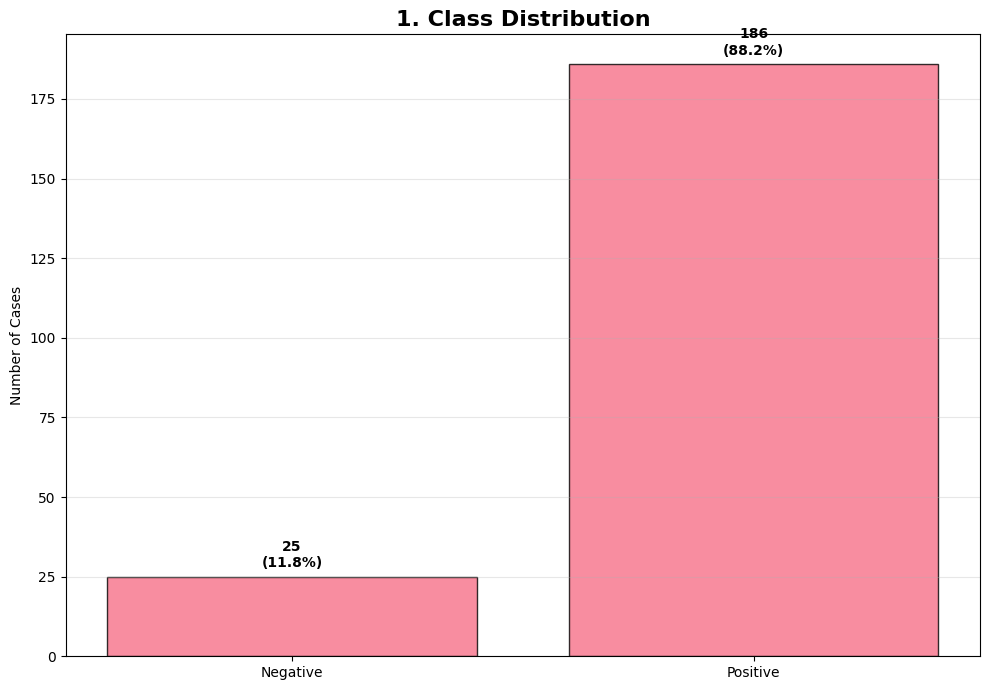

In [ ]:
plt.figure(figsize=(10, 7))

class_counts = y.value_counts().sort_index()
labels = ["Negative", "Positive"]
values = [class_counts.get(0, 0), class_counts.get(1, 0)]

bars = plt.bar(labels, values, alpha=0.8, edgecolor="black")

plt.title("1. Class Distribution", fontsize=16, fontweight="bold")
plt.ylabel("Number of Cases")

for bar, value in zip(bars, values):
    pct = value / len(y) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{value}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

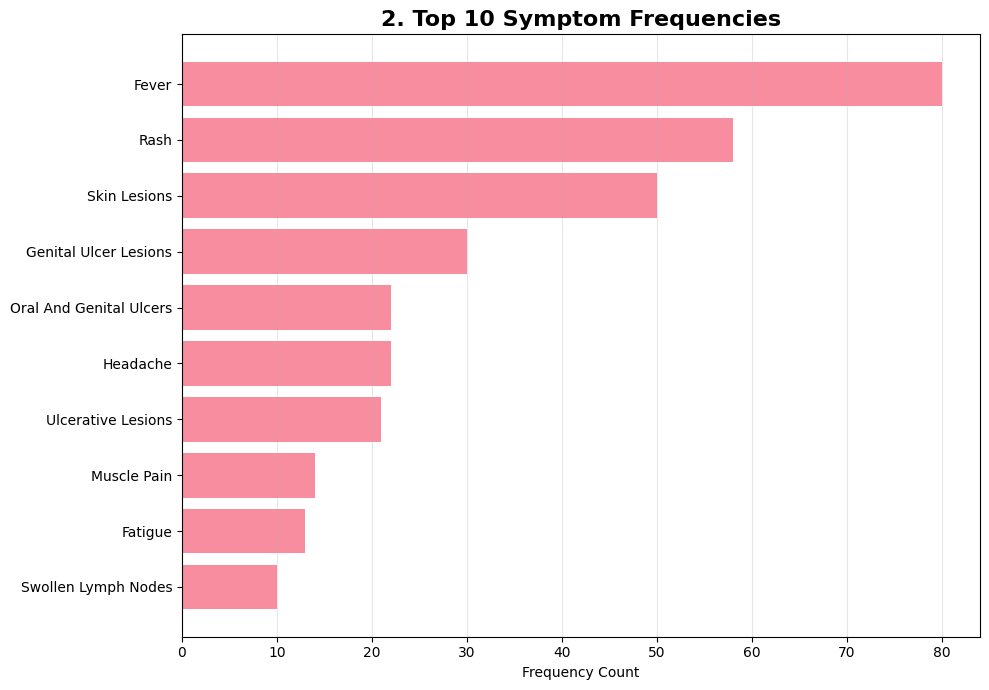

In [ ]:
plt.figure(figsize=(10, 7))

symptom_freq = X.sum().sort_values(ascending=True)
top_symptoms = symptom_freq.tail(10)

plt.barh(
    range(len(top_symptoms)),
    top_symptoms.values,
    alpha=0.8
)

plt.yticks(
    range(len(top_symptoms)),
    [str(s).replace("_", " ").title() for s in top_symptoms.index]
)

plt.xlabel("Frequency Count")
plt.title("2. Top 10 Symptom Frequencies", fontsize=16, fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_02_symptom_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

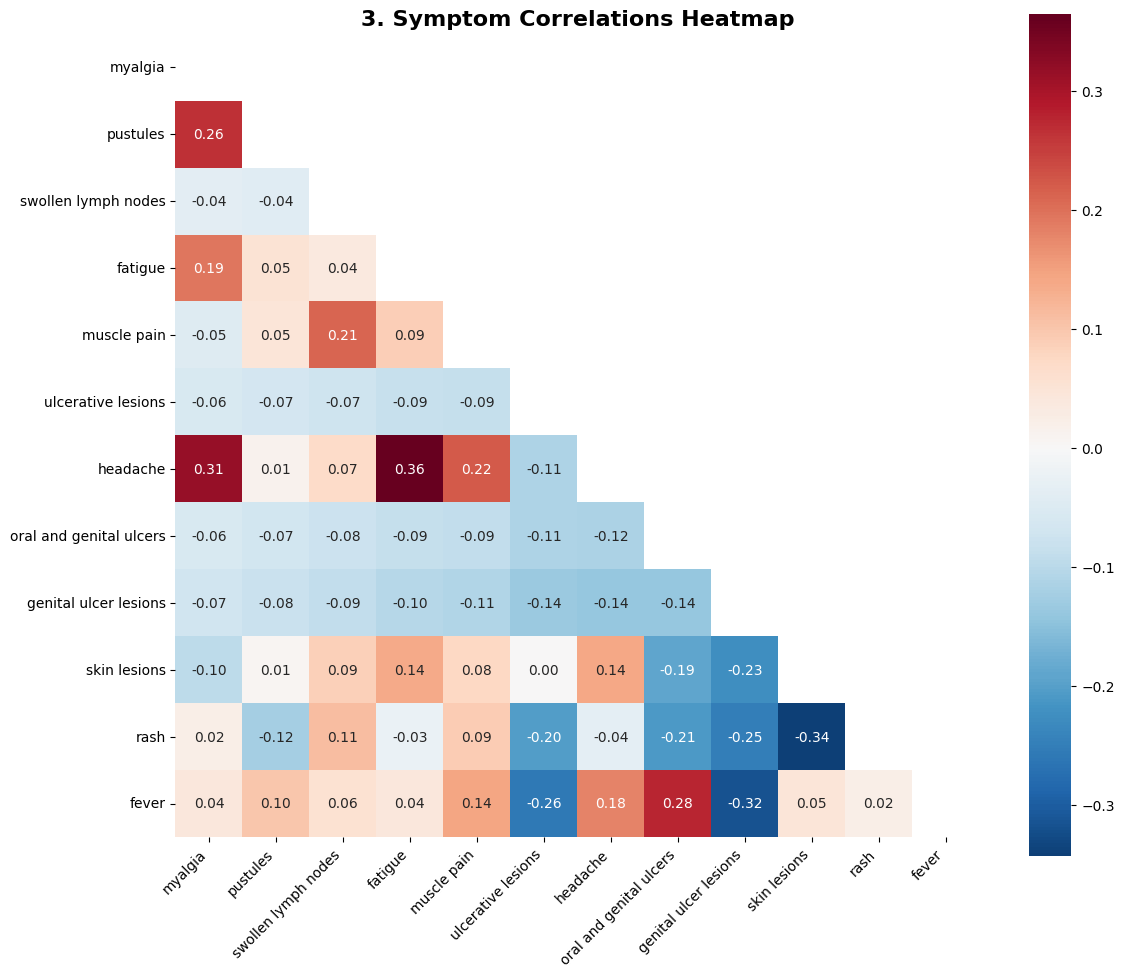

In [ ]:
plt.figure(figsize=(12, 10))

corr_matrix = X.corr()
heatmap_features = symptom_freq.tail(min(12, len(symptom_freq))).index
corr_subset = corr_matrix.loc[heatmap_features, heatmap_features]
mask = np.triu(np.ones_like(corr_subset, dtype=bool))

sns.heatmap(
    corr_subset,
    mask=mask,
    annot=True,
    cmap="RdBu_r",
    center=0,
    square=True,
    fmt=".2f"
)

plt.title("3. Symptom Correlations Heatmap", fontsize=16, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("figure_03_symptom_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

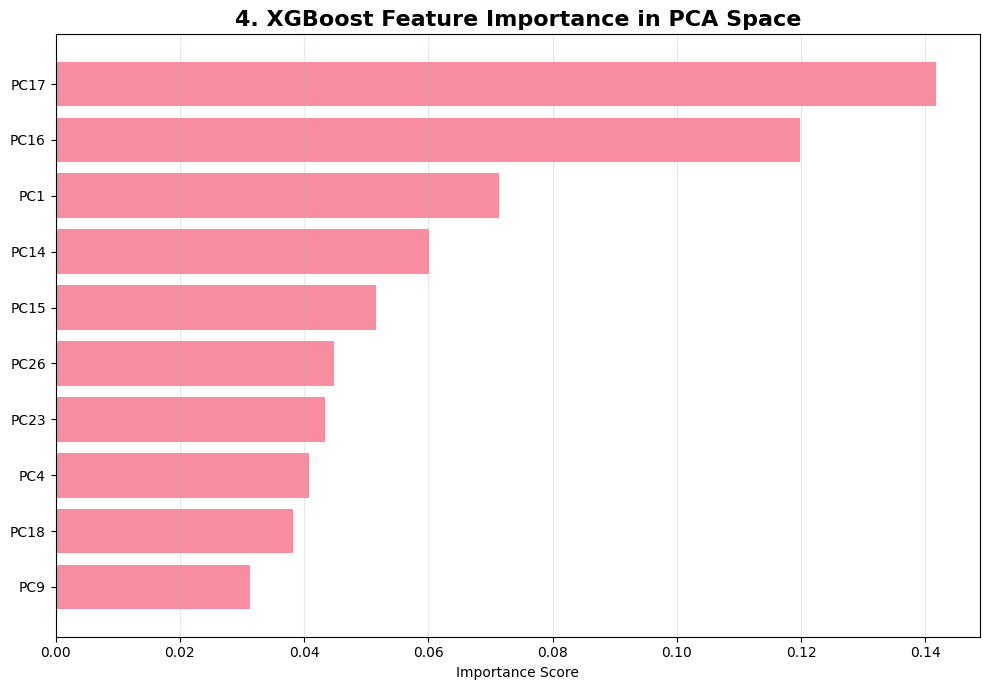

In [ ]:
plt.figure(figsize=(10, 7))

importance = xgb_model.feature_importances_
top_idx = np.argsort(importance)[-10:]

plt.barh(
    range(len(top_idx)),
    importance[top_idx],
    alpha=0.8
)

plt.yticks(
    range(len(top_idx)),
    [f"PC{i+1}" for i in top_idx]
)

plt.xlabel("Importance Score")
plt.title("4. XGBoost Feature Importance in PCA Space", fontsize=16, fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_04_xgb_pca_importance.png", dpi=300, bbox_inches="tight")
plt.show()

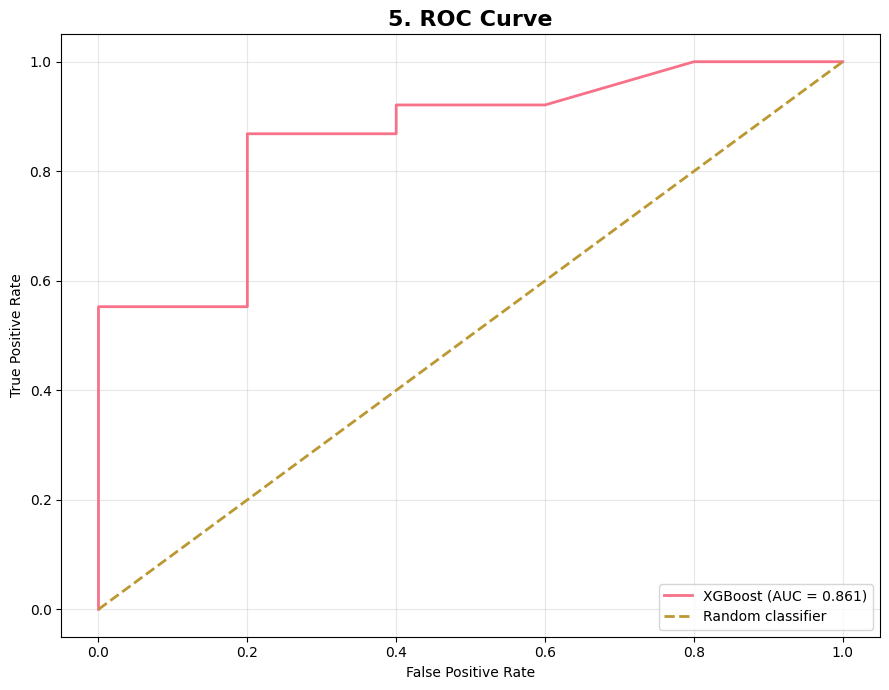

In [ ]:
plt.figure(figsize=(9, 7))

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.plot(fpr, tpr, linewidth=2, label=f"XGBoost (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("5. ROC Curve", fontsize=16, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figure_05_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

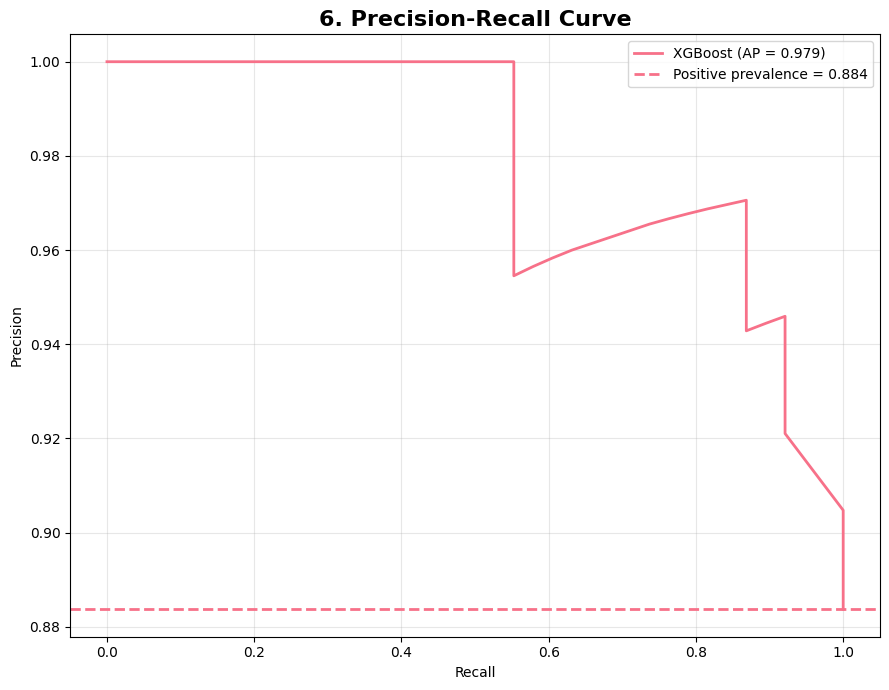

In [ ]:
plt.figure(figsize=(9, 7))

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)
prevalence = float(y_test.mean())

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"XGBoost (AP = {pr_auc:.3f})"
)

plt.axhline(
    prevalence,
    linestyle="--",
    linewidth=2,
    label=f"Positive prevalence = {prevalence:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("6. Precision-Recall Curve", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figure_06_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

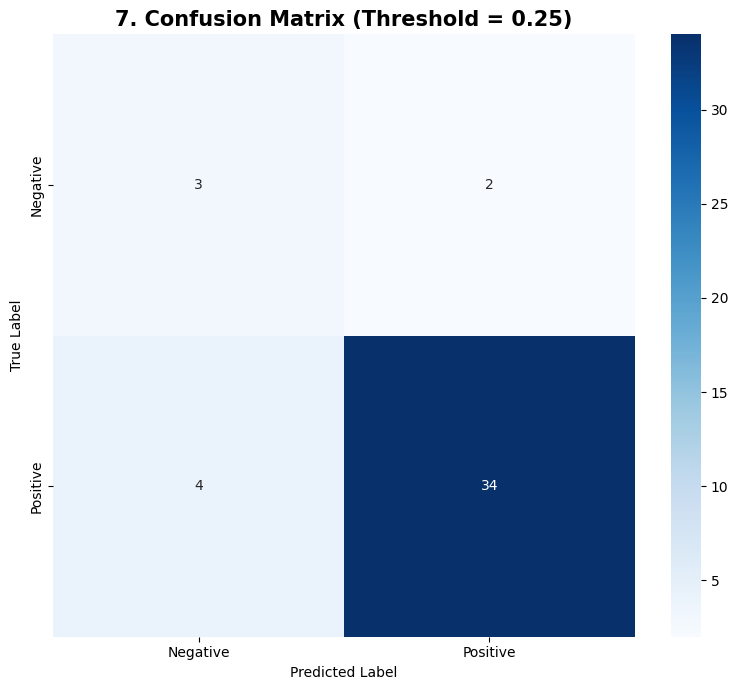

In [ ]:
plt.figure(figsize=(8, 7))

cm = confusion_matrix(y_test, y_test_pred_tuned, labels=[0, 1])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(
    f"7. Confusion Matrix (Threshold = {selected_threshold:.2f})",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("figure_07_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

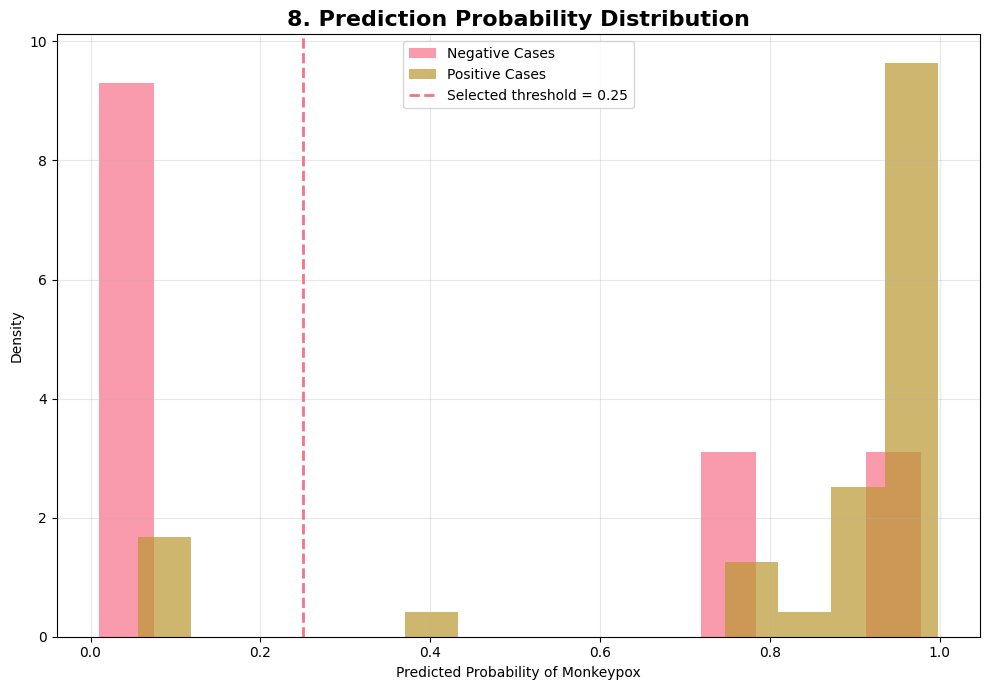

In [ ]:
plt.figure(figsize=(10, 7))

negative_probs = y_test_proba[np.asarray(y_test) == 0]
positive_probs = y_test_proba[np.asarray(y_test) == 1]

if len(negative_probs):
    plt.hist(negative_probs, bins=15, alpha=0.7, density=True, label="Negative Cases")
if len(positive_probs):
    plt.hist(positive_probs, bins=15, alpha=0.7, density=True, label="Positive Cases")

plt.axvline(
    selected_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Selected threshold = {selected_threshold:.2f}"
)

plt.xlabel("Predicted Probability of Monkeypox")
plt.ylabel("Density")
plt.title("8. Prediction Probability Distribution", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figure_08_probability_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

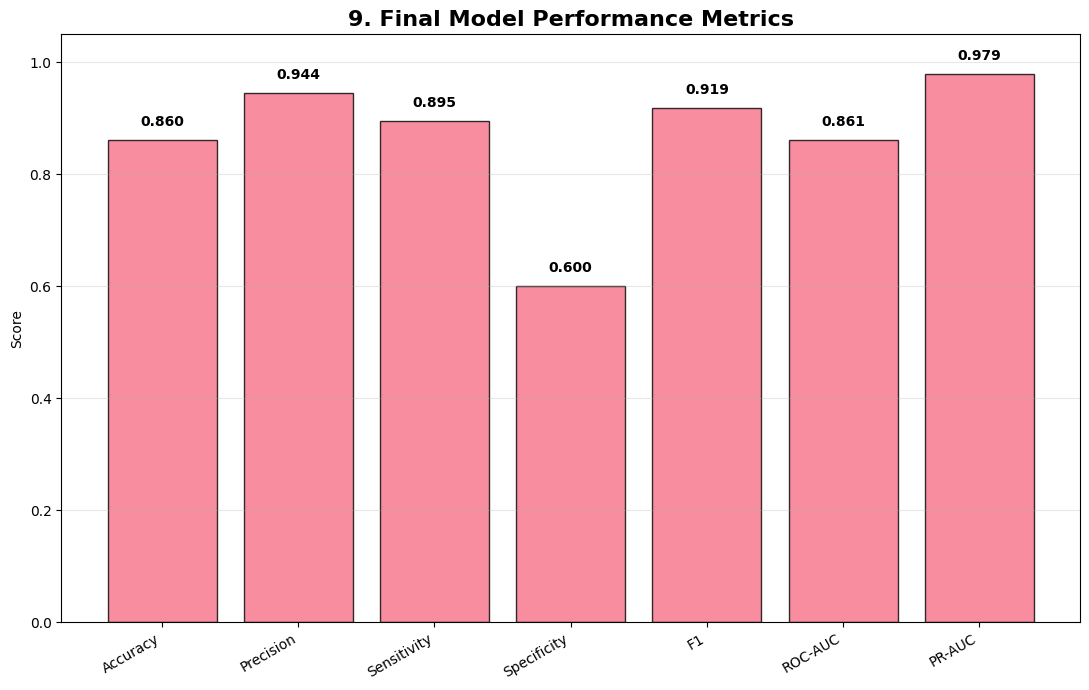

In [ ]:
plt.figure(figsize=(11, 7))

metric_names = [
    "Accuracy", "Precision", "Sensitivity", "Specificity",
    "F1", "ROC-AUC", "PR-AUC"
]
metric_values = [
    accuracy, precision, recall, specificity, f1,
    roc_auc_score_value, pr_auc_score_value
]

bars = plt.bar(
    metric_names,
    metric_values,
    alpha=0.8,
    edgecolor="black"
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("9. Final Model Performance Metrics", fontsize=16, fontweight="bold")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        min(value + 0.02, 1.01),
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_09_final_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

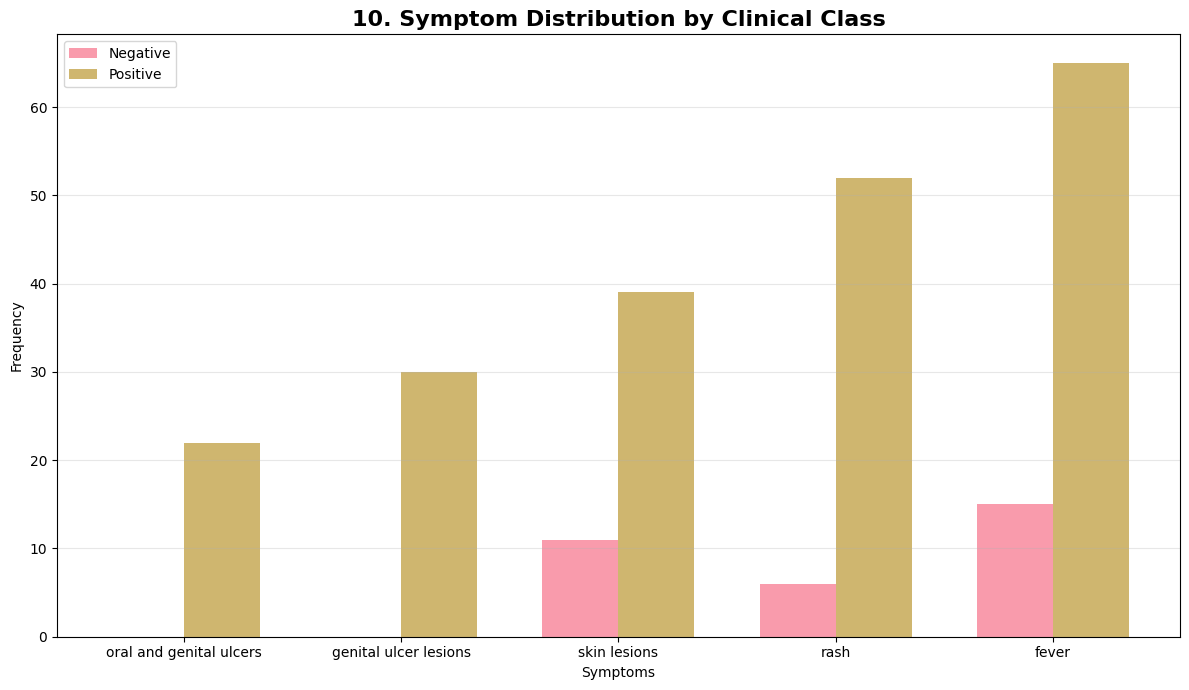

In [ ]:
plt.figure(figsize=(12, 7))

positive_freq = X.loc[y == 1].sum()
negative_freq = X.loc[y == 0].sum()

important_symptoms = symptom_freq.tail(min(5, len(symptom_freq))).index
xpos = np.arange(len(important_symptoms))
width = 0.35

plt.bar(
    xpos - width/2,
    [negative_freq[s] for s in important_symptoms],
    width,
    alpha=0.7,
    label="Negative"
)

plt.bar(
    xpos + width/2,
    [positive_freq[s] for s in important_symptoms],
    width,
    alpha=0.7,
    label="Positive"
)

plt.xticks(
    xpos,
    [str(s).replace("_", "\n") for s in important_symptoms]
)
plt.ylabel("Frequency")
plt.xlabel("Symptoms")
plt.title("10. Symptom Distribution by Clinical Class", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_10_symptom_distribution_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

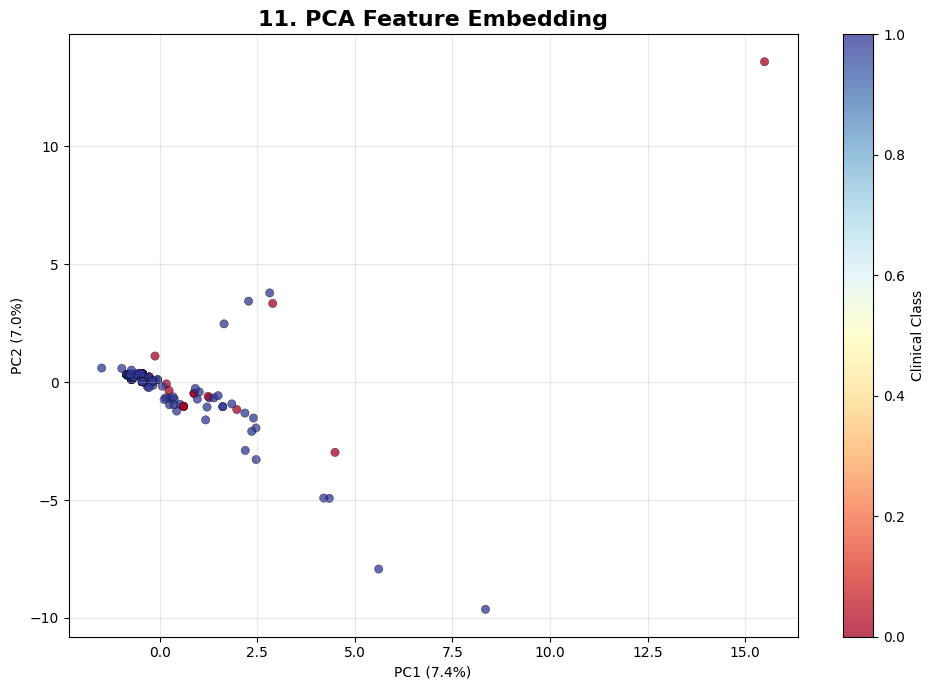

In [ ]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2d.fit(X_train_scaled)
X_all_scaled = scaler.transform(imputer.transform(X))
X_all_pca_2d = pca_2d.transform(X_all_scaled)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_all_pca_2d[:, 0],
    X_all_pca_2d[:, 1],
    c=y,
    cmap="RdYlBu",
    alpha=0.75,
    edgecolors="black",
    linewidths=0.3
)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
plt.title("11. PCA Feature Embedding", fontsize=16, fontweight="bold")
plt.colorbar(scatter, label="Clinical Class")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figure_11_pca_embedding.png", dpi=300, bbox_inches="tight")
plt.show()

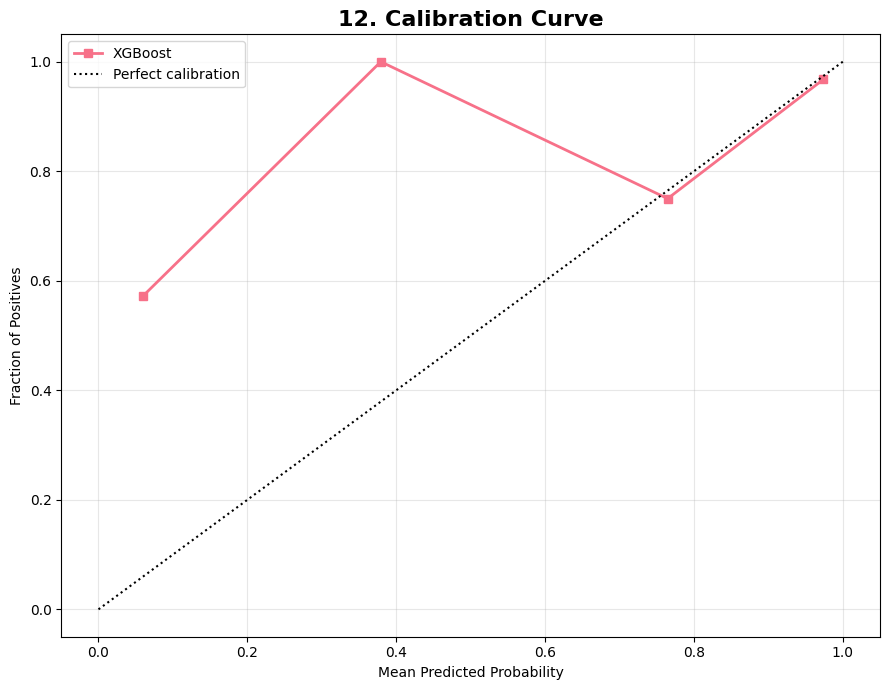

In [ ]:
plt.figure(figsize=(9, 7))

frac_pos, mean_pred = calibration_curve(
    y_test,
    y_test_proba,
    n_bins=5,
    strategy="uniform"
)

plt.plot(
    mean_pred,
    frac_pos,
    "s-",
    linewidth=2,
    label="XGBoost"
)
plt.plot(
    [0, 1],
    [0, 1],
    "k:",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("12. Calibration Curve", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figure_12_calibration_curve.png", dpi=300, bbox_inches="tight")
plt.show()

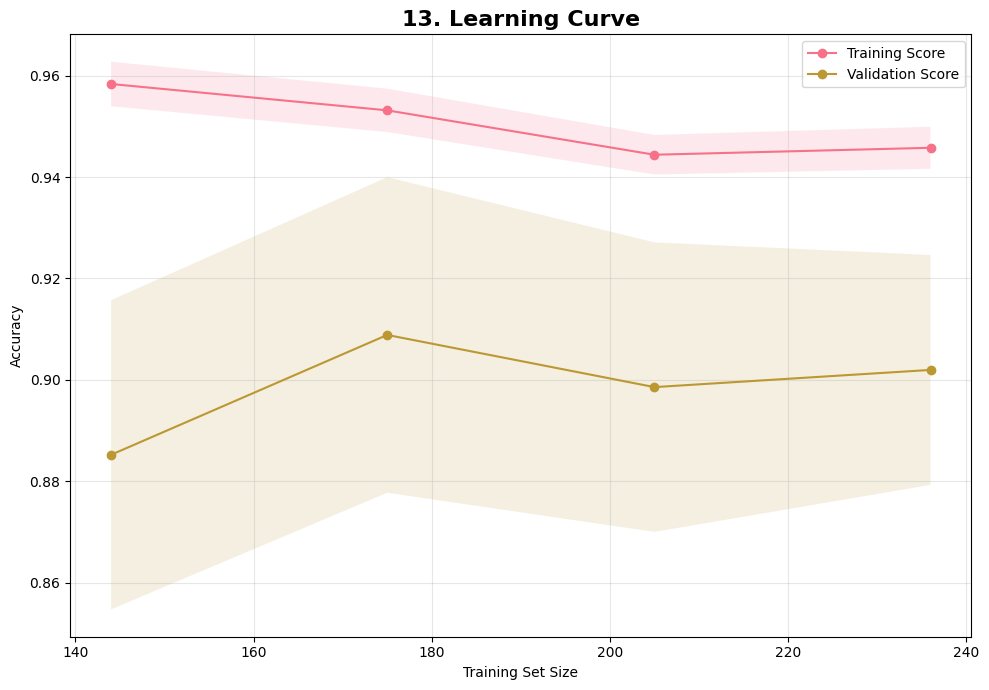

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb_model,
    X_train_balanced,
    y_train_balanced,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_mean, "o-", label="Training Score")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, "o-", label="Validation Score")
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15)

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("13. Learning Curve", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figure_13_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

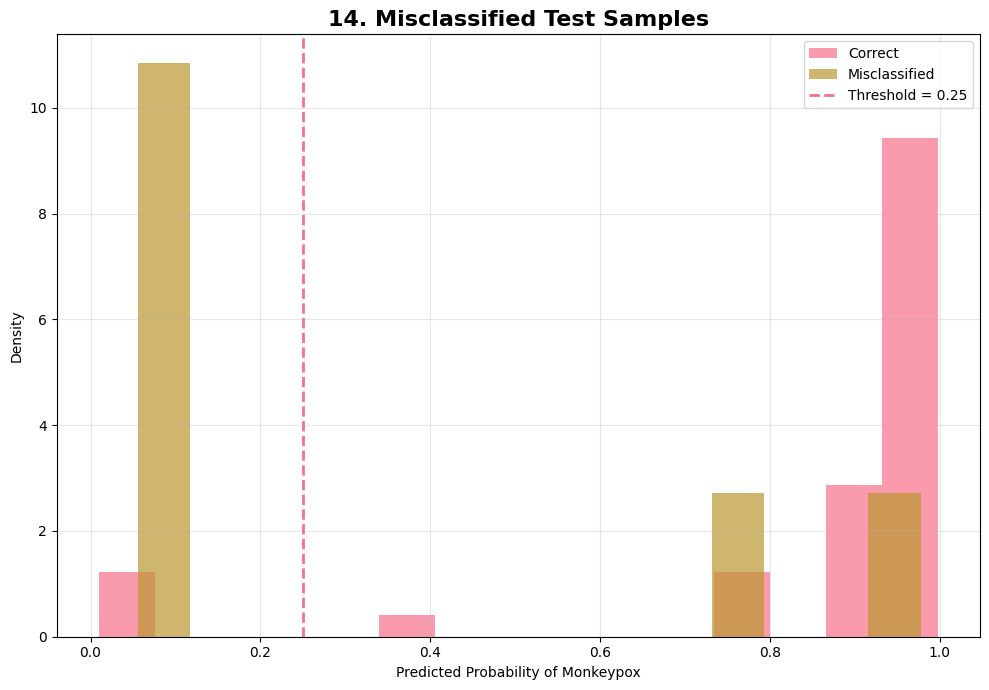

Misclassified test samples: 6 / 43


In [ ]:
plt.figure(figsize=(10, 7))

incorrect = np.asarray(y_test) != np.asarray(y_test_pred_tuned)

correct_probs = y_test_proba[~incorrect]
incorrect_probs = y_test_proba[incorrect]

if len(correct_probs):
    plt.hist(correct_probs, bins=15, alpha=0.7, density=True, label="Correct")
if len(incorrect_probs):
    plt.hist(incorrect_probs, bins=15, alpha=0.7, density=True, label="Misclassified")

plt.axvline(selected_threshold, linestyle="--", linewidth=2, label=f"Threshold = {selected_threshold:.2f}")
plt.xlabel("Predicted Probability of Monkeypox")
plt.ylabel("Density")
plt.title("14. Misclassified Test Samples", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figure_14_misclassified_samples.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Misclassified test samples: {incorrect.sum()} / {len(y_test)}")

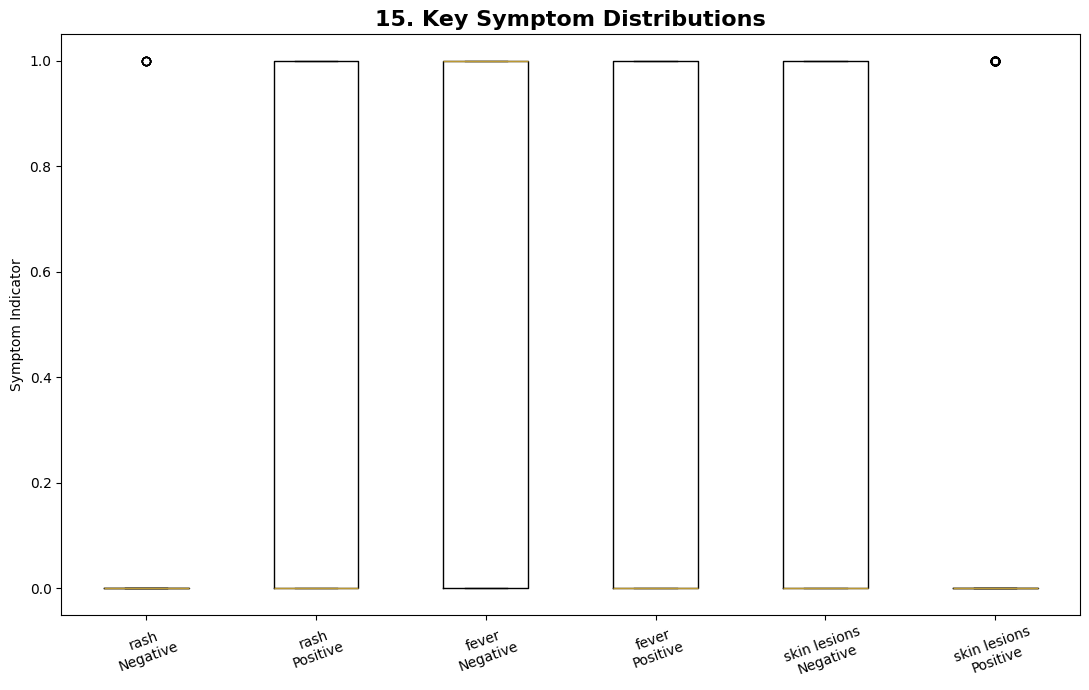

In [ ]:
candidate_symptoms = [
    "rash",
    "fever",
    "skin lesions",
    "headache",
    "lymphadenopathy"
]

available = [s for s in candidate_symptoms if s in X.columns]

if available:
    plot_data = []
    labels = []

    for symptom in available[:3]:
        plot_data.append(X.loc[y == 0, symptom].values)
        labels.append(f"{symptom}\nNegative")
        plot_data.append(X.loc[y == 1, symptom].values)
        labels.append(f"{symptom}\nPositive")

    plt.figure(figsize=(11, 7))
    plt.boxplot(plot_data, tick_labels=labels)
    plt.ylabel("Symptom Indicator")
    plt.title("15. Key Symptom Distributions", fontsize=16, fontweight="bold")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig("figure_15_key_symptom_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No requested symptom names were found; skipping Figure 15.")

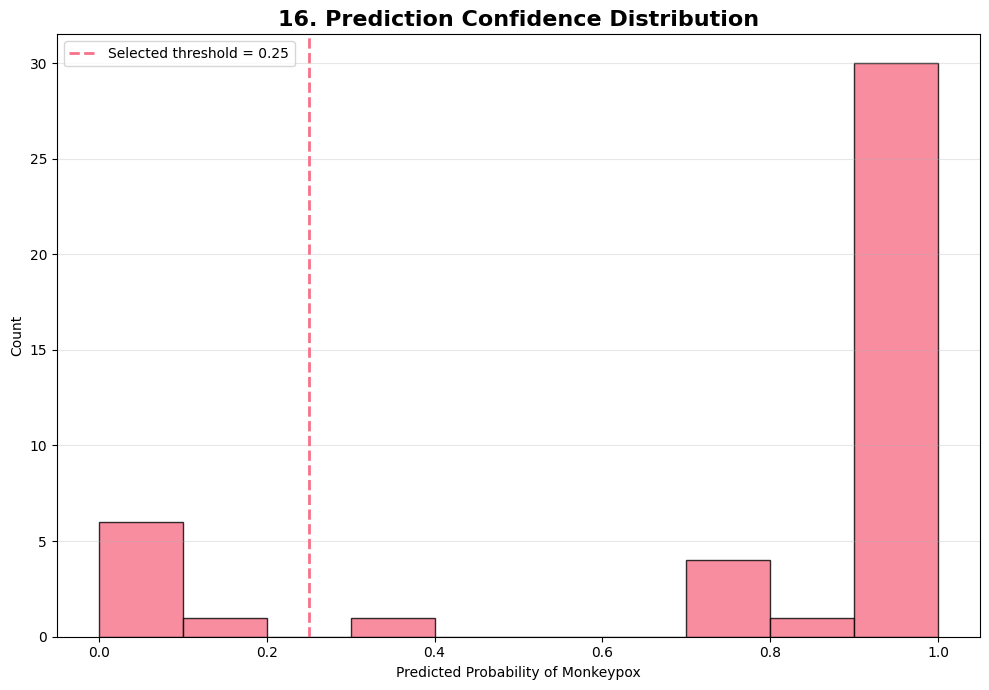

In [ ]:
# =============================================================================
# FIGURE 16: PREDICTION CONFIDENCE DISTRIBUTION
# =============================================================================

plt.figure(figsize=(10, 7))

plt.hist(
    y_test_proba,
    bins=np.linspace(0, 1, 11),
    alpha=0.8,
    edgecolor="black"
)

plt.axvline(
    selected_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Selected threshold = {selected_threshold:.2f}"
)

plt.xlabel("Predicted Probability of Monkeypox")
plt.ylabel("Count")
plt.title("16. Prediction Confidence Distribution", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_16_prediction_confidence.png", dpi=300, bbox_inches="tight")
plt.show()

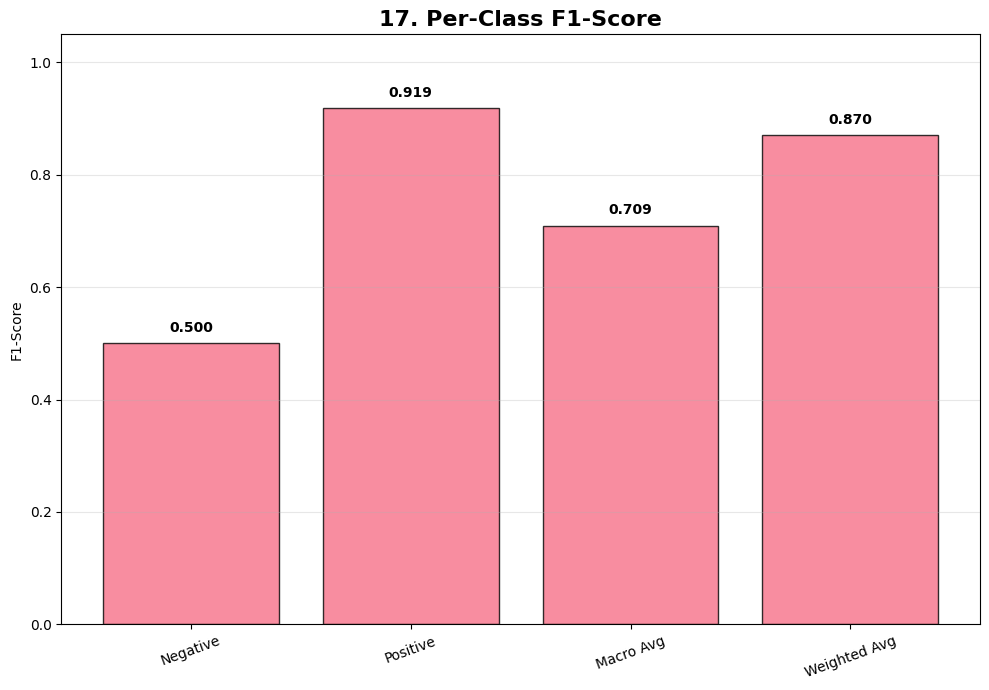

In [ ]:
report = classification_report(
    y_test,
    y_test_pred_tuned,
    labels=[0, 1],
    target_names=["Negative", "Positive"],
    output_dict=True,
    zero_division=0
)

classes = ["Negative", "Positive", "Macro Avg", "Weighted Avg"]
values = [
    report["Negative"]["f1-score"],
    report["Positive"]["f1-score"],
    report["macro avg"]["f1-score"],
    report["weighted avg"]["f1-score"]
]

plt.figure(figsize=(10, 7))
bars = plt.bar(classes, values, alpha=0.8, edgecolor="black")
plt.ylim(0, 1.05)
plt.ylabel("F1-Score")
plt.title("17. Per-Class F1-Score", fontsize=16, fontweight="bold")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        min(value + 0.02, 1.02),
        f"{value:.3f}",
        ha="center",
        fontweight="bold"
    )

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_17_per_class_f1.png", dpi=300, bbox_inches="tight")
plt.show()

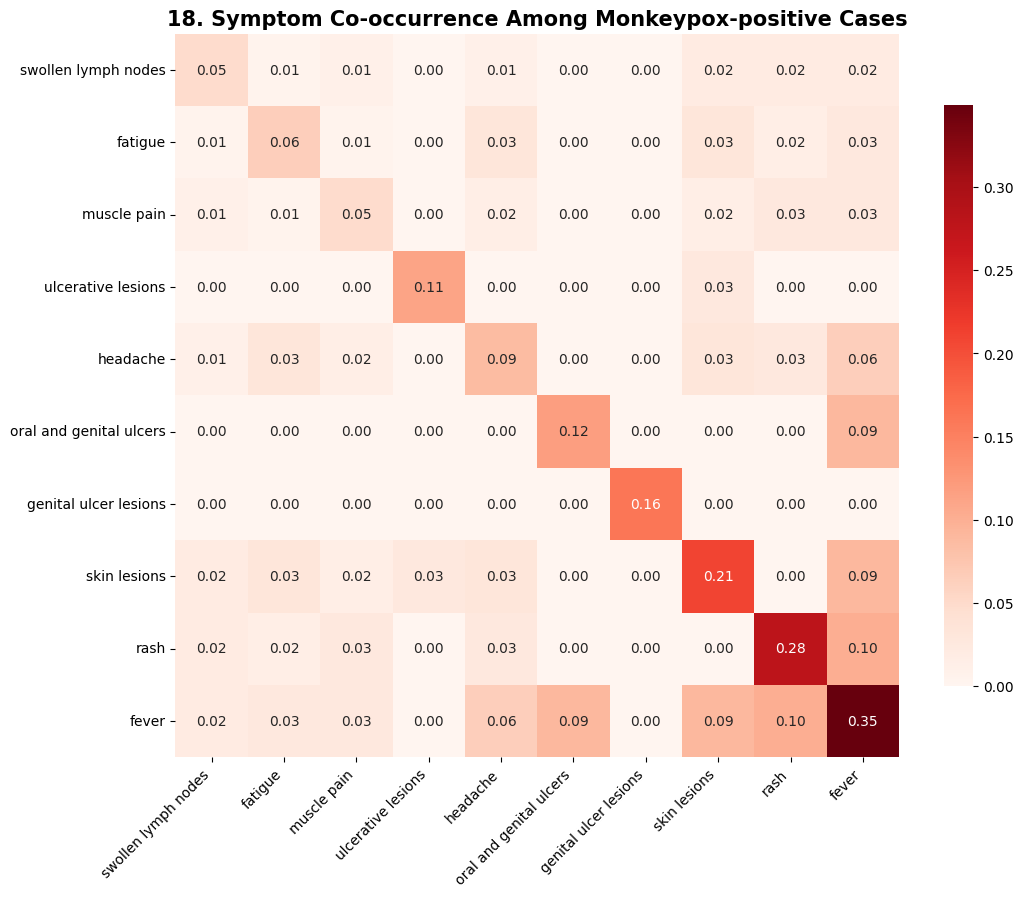

In [ ]:
positive_cases = X.loc[y == 1]

if len(positive_cases) > 0:
    cooccurrence = positive_cases.T.dot(positive_cases) / len(positive_cases)
    cooc_features = symptom_freq.tail(min(10, len(symptom_freq))).index
    cooc_subset = cooccurrence.loc[cooc_features, cooc_features]

    plt.figure(figsize=(11, 9))
    sns.heatmap(
        cooc_subset,
        cmap="Reds",
        square=True,
        annot=True,
        fmt=".2f",
        cbar_kws={"shrink": 0.8}
    )
    plt.title("18. Symptom Co-occurrence Among Monkeypox-positive Cases", fontsize=15, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("figure_18_symptom_cooccurrence.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No positive observations available for co-occurrence analysis.")

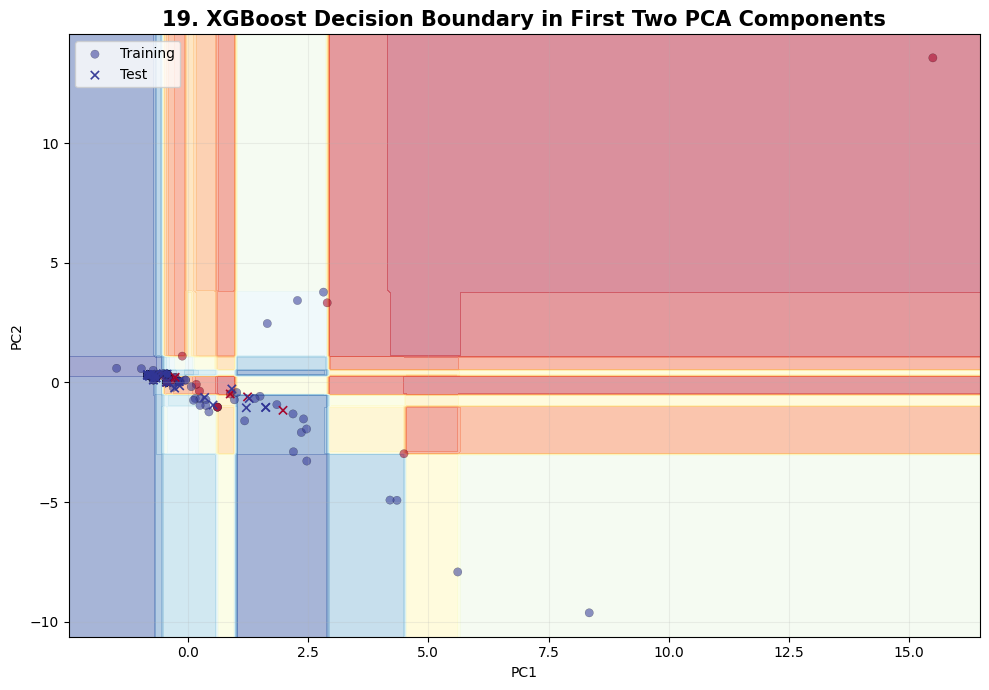

In [ ]:
boundary_model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

boundary_model.fit(
    X_train_balanced[:, :2],
    y_train_balanced
)

plot_points = np.vstack([X_train_pca[:, :2], X_test_pca[:, :2]])

x_min, x_max = plot_points[:, 0].min() - 1, plot_points[:, 0].max() + 1
y_min, y_max = plot_points[:, 1].min() - 1, plot_points[:, 1].max() + 1

h = 0.08
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = boundary_model.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, levels=30, cmap="RdYlBu", alpha=0.45)

train_labels = np.asarray(y_train)
test_labels = np.asarray(y_test)

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=train_labels,
    cmap="RdYlBu",
    alpha=0.55,
    marker="o",
    edgecolors="black",
    linewidths=0.2,
    label="Training"
)

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=test_labels,
    cmap="RdYlBu",
    alpha=0.95,
    marker="x",
    linewidths=1.2,
    label="Test"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("19. XGBoost Decision Boundary in First Two PCA Components", fontsize=15, fontweight="bold")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("figure_19_decision_boundary.png", dpi=300, bbox_inches="tight")
plt.show()

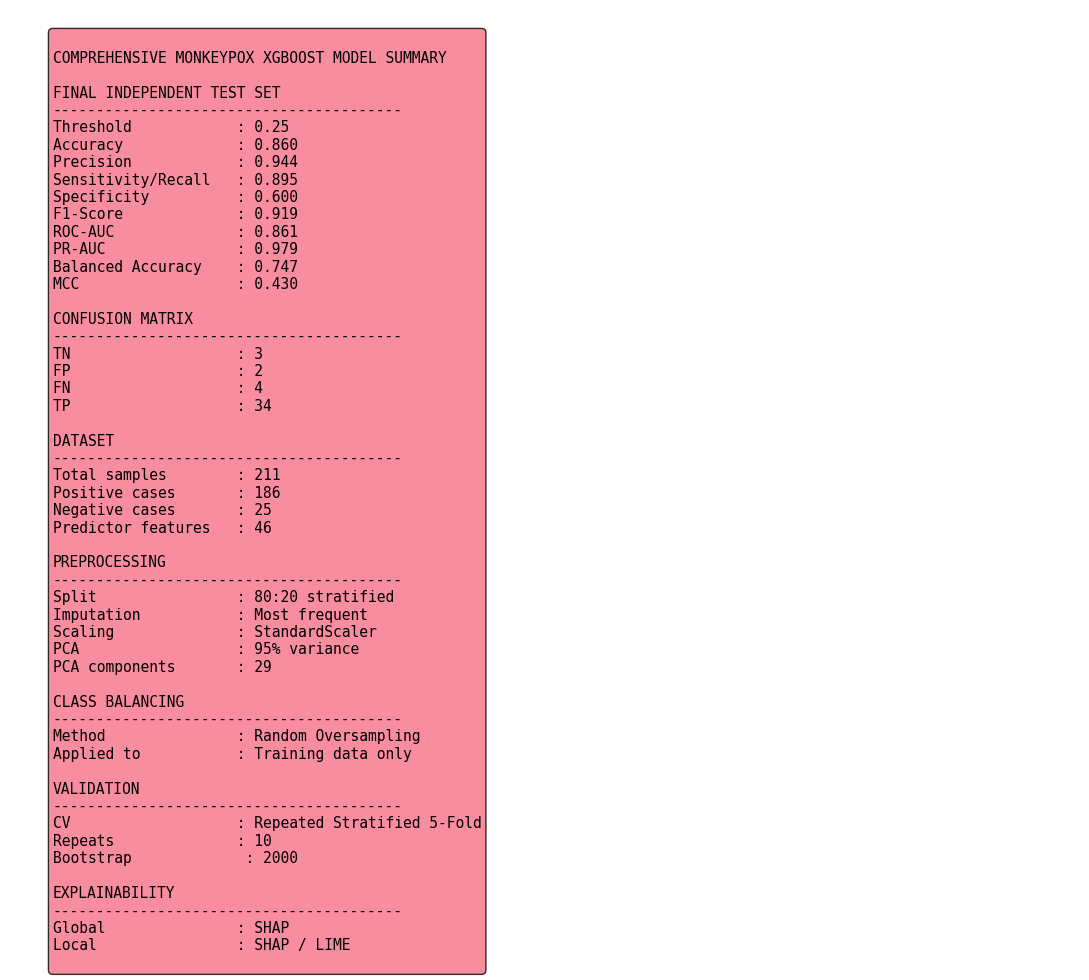

In [ ]:
plt.figure(figsize=(11, 10))
plt.axis("off")

summary_text = f"""
COMPREHENSIVE MONKEYPOX XGBOOST MODEL SUMMARY

FINAL INDEPENDENT TEST SET
----------------------------------------
Threshold            : {selected_threshold:.2f}
Accuracy             : {accuracy:.3f}
Precision            : {precision:.3f}
Sensitivity/Recall   : {recall:.3f}
Specificity          : {specificity:.3f}
F1-Score             : {f1:.3f}
ROC-AUC              : {roc_auc_score_value:.3f}
PR-AUC               : {pr_auc_score_value:.3f}
Balanced Accuracy    : {balanced_acc:.3f}
MCC                  : {mcc:.3f}

CONFUSION MATRIX
----------------------------------------
TN                   : {tn}
FP                   : {fp}
FN                   : {fn}
TP                   : {tp}

DATASET
----------------------------------------
Total samples        : {len(df)}
Positive cases       : {(y == 1).sum()}
Negative cases       : {(y == 0).sum()}
Predictor features   : {X.shape[1]}

PREPROCESSING
----------------------------------------
Split                : 80:20 stratified
Imputation           : Most frequent
Scaling              : StandardScaler
PCA                  : 95% variance
PCA components       : {X_train_pca.shape[1]}

CLASS BALANCING
----------------------------------------
Method               : Random Oversampling
Applied to           : Training data only

VALIDATION
----------------------------------------
CV                   : Repeated Stratified 5-Fold
Repeats              : {CV_REPEATS}
Bootstrap             : {N_BOOTSTRAP}

EXPLAINABILITY
----------------------------------------
Global               : SHAP
Local                : SHAP / LIME
"""

plt.text(
    0.04,
    0.97,
    summary_text,
    transform=plt.gca().transAxes,
    fontsize=10.5,
    va="top",
    family="monospace",
    bbox=dict(boxstyle="round", alpha=0.8)
)

plt.tight_layout()
plt.savefig("figure_20_comprehensive_summary.png", dpi=300, bbox_inches="tight")
plt.show()

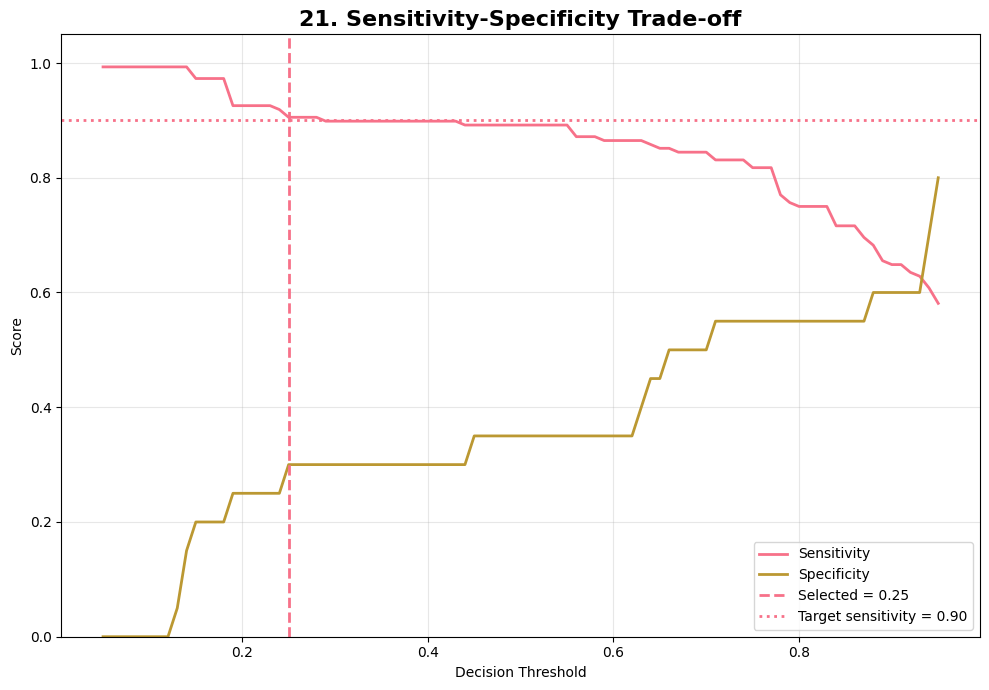

In [ ]:
plt.figure(figsize=(10, 7))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Sensitivity"],
    linewidth=2,
    label="Sensitivity"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Specificity"],
    linewidth=2,
    label="Specificity"
)

plt.axvline(
    selected_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Selected = {selected_threshold:.2f}"
)

plt.axhline(
    TARGET_SENSITIVITY,
    linestyle=":",
    linewidth=2,
    label=f"Target sensitivity = {TARGET_SENSITIVITY:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("21. Sensitivity-Specificity Trade-off", fontsize=16, fontweight="bold")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("figure_21_threshold_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

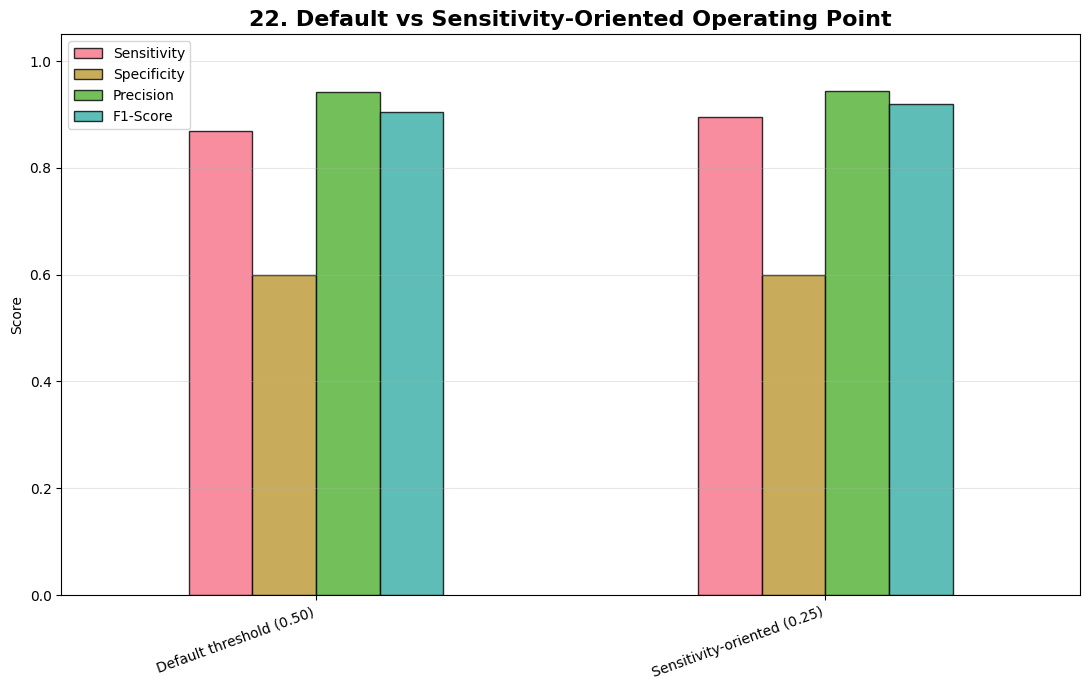

In [ ]:
# =============================================================================
# FIGURE 22: DEFAULT VS TUNED OPERATING POINT
# =============================================================================

comparison_plot_df = comparison_metrics.loc[
    ["Default threshold (0.50)", f"Sensitivity-oriented ({selected_threshold:.2f})"],
    ["Sensitivity", "Specificity", "Precision", "F1-Score"]
]

ax = comparison_plot_df.plot(
    kind="bar",
    figsize=(11, 7),
    alpha=0.8,
    edgecolor="black"
)

ax.set_title("22. Default vs Sensitivity-Oriented Operating Point", fontsize=16, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figure_22_default_vs_tuned.png", dpi=300, bbox_inches="tight")
plt.show()

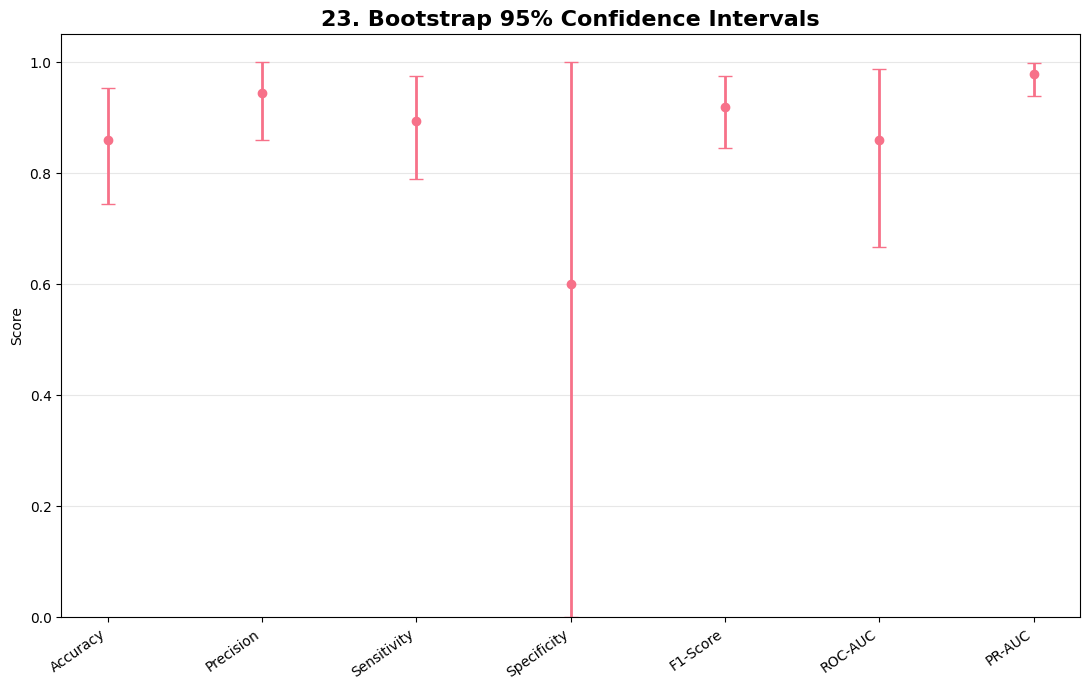

In [ ]:
plt.figure(figsize=(11, 7))

plot_ci = bootstrap_ci_df.copy()
x = np.arange(len(plot_ci))
est = plot_ci["Estimate"].values
lower_err = est - plot_ci["Lower 95%"].values
upper_err = plot_ci["Upper 95%"].values - est

plt.errorbar(
    x,
    est,
    yerr=[lower_err, upper_err],
    fmt="o",
    capsize=5,
    linewidth=2
)

plt.xticks(
    x,
    plot_ci["Metric"],
    rotation=35,
    ha="right"
)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("23. Bootstrap 95% Confidence Intervals", fontsize=16, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_23_bootstrap_ci.png", dpi=300, bbox_inches="tight")
plt.show()

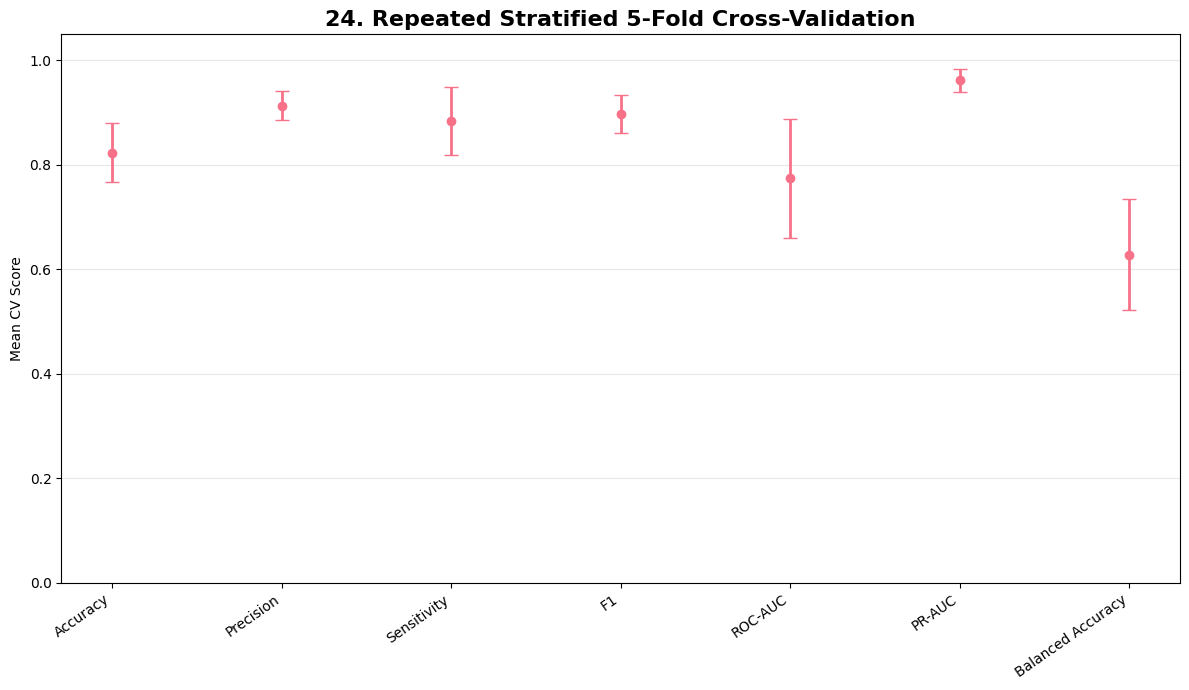

In [ ]:
cv_plot = cv_summary_df.copy()
cv_plot["Metric"] = cv_plot["Metric"].replace({
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Sensitivity",
    "f1": "F1",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "balanced_accuracy": "Balanced Accuracy"
})

plt.figure(figsize=(12, 7))

x = np.arange(len(cv_plot))
plt.errorbar(
    x,
    cv_plot["Mean"],
    yerr=cv_plot["SD"],
    fmt="o",
    capsize=5,
    linewidth=2
)

plt.xticks(
    x,
    cv_plot["Metric"],
    rotation=35,
    ha="right"
)
plt.ylabel("Mean CV Score")
plt.ylim(0, 1.05)
plt.title("24. Repeated Stratified 5-Fold Cross-Validation", fontsize=16, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure_24_repeated_cv.png", dpi=300, bbox_inches="tight")
plt.show()

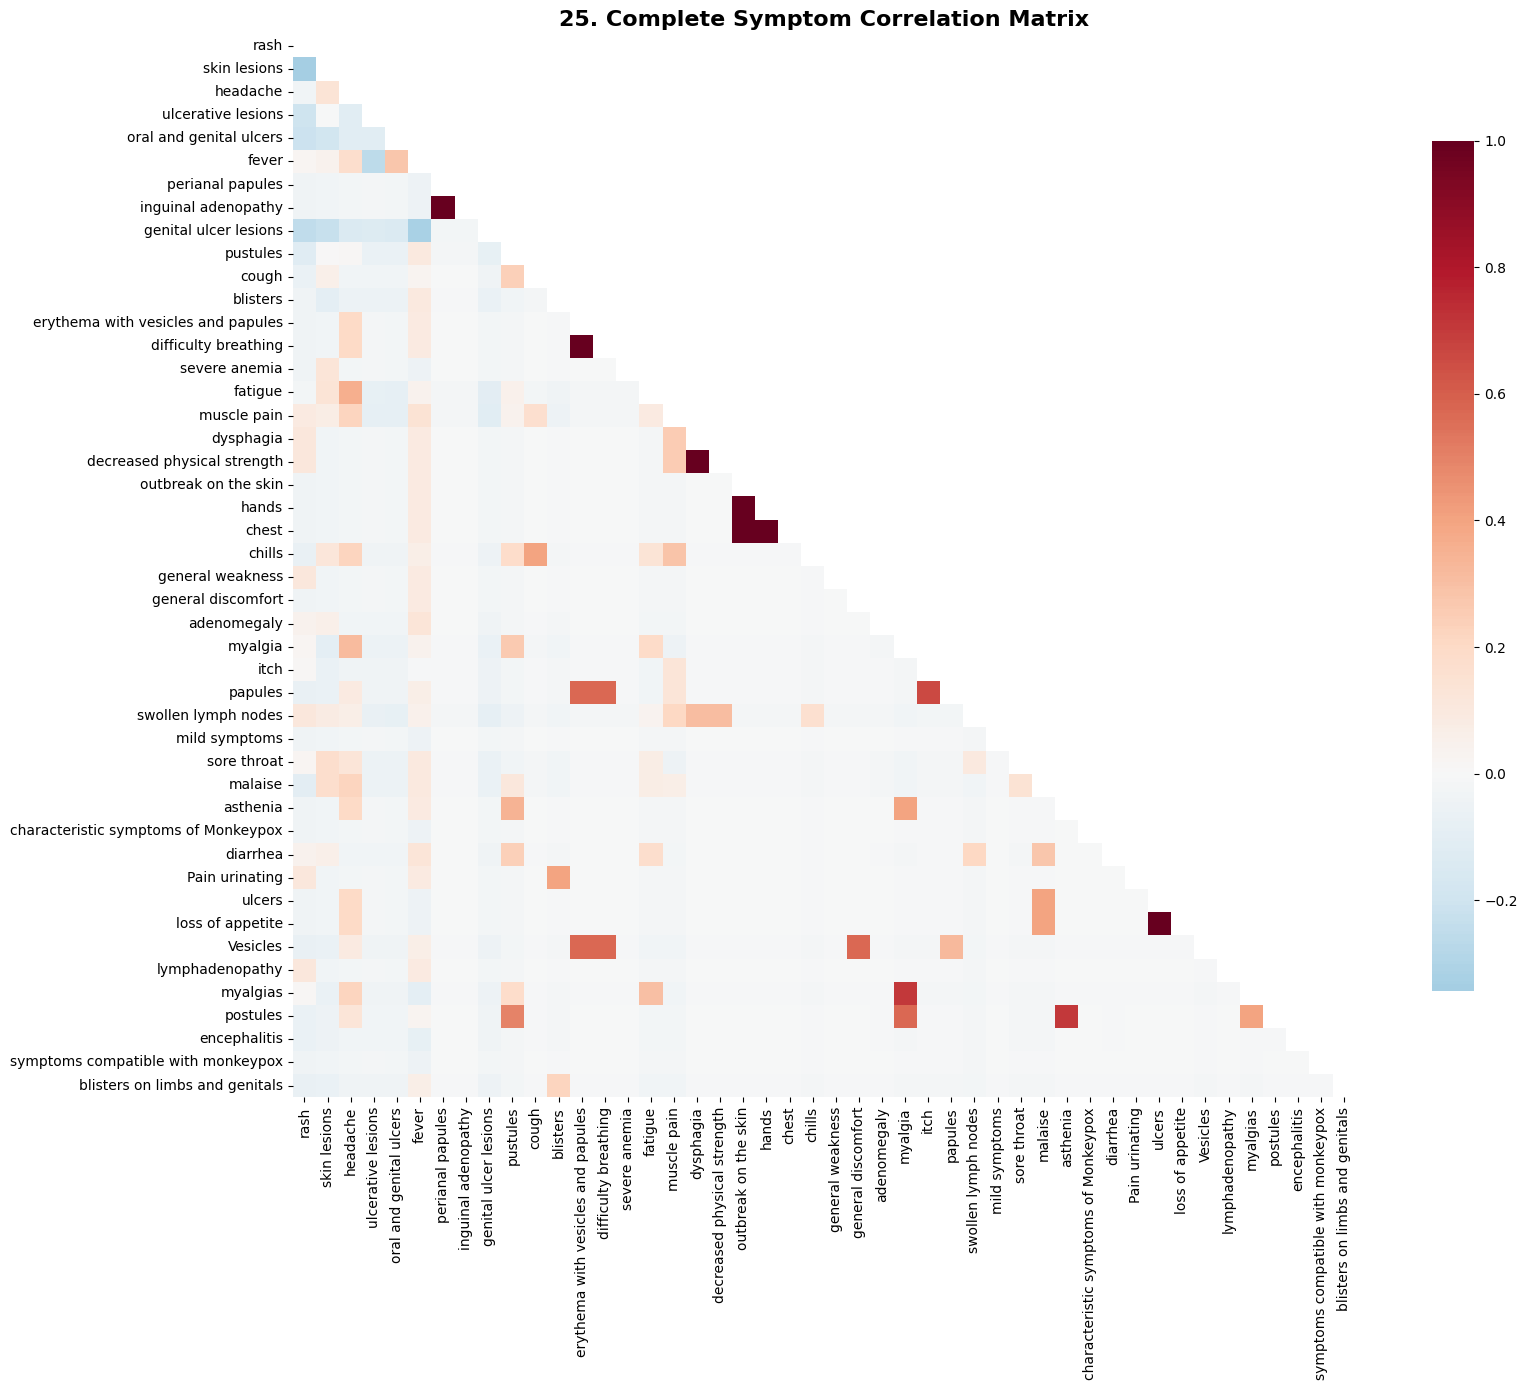

In [ ]:
plt.figure(figsize=(18, 14))
full_corr = X.corr()
mask = np.triu(np.ones_like(full_corr, dtype=bool))

sns.heatmap(
    full_corr,
    mask=mask,
    annot=False,
    cmap="RdBu_r",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("25. Complete Symptom Correlation Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("figure_25_complete_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

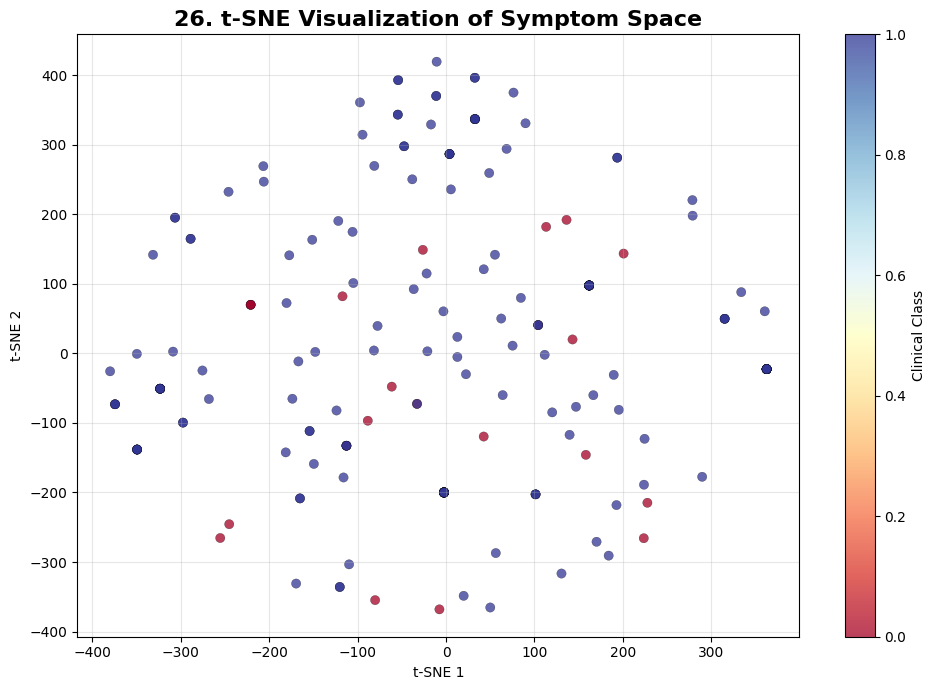

In [ ]:
if len(X_all_scaled) > 50:
    perplexity = min(30, max(5, len(X_all_scaled) // 4))

    tsne = TSNE(
        n_components=2,
        random_state=RANDOM_STATE,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto"
    )

    X_tsne = tsne.fit_transform(X_all_scaled)

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=y,
        cmap="RdYlBu",
        alpha=0.75,
        s=45,
        edgecolors="black",
        linewidths=0.2
    )

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title("26. t-SNE Visualization of Symptom Space", fontsize=16, fontweight="bold")
    plt.colorbar(scatter, label="Clinical Class")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("figure_26_tsne.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Dataset too small for this t-SNE configuration.")


🔬 STEP 10: SHAP EXPLAINABILITY
-----------------------------------------------------------------


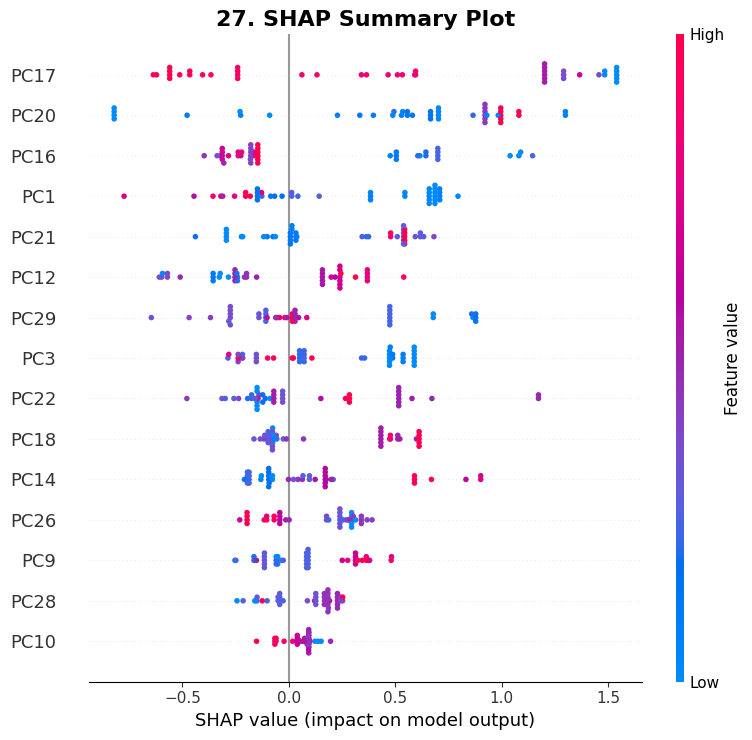

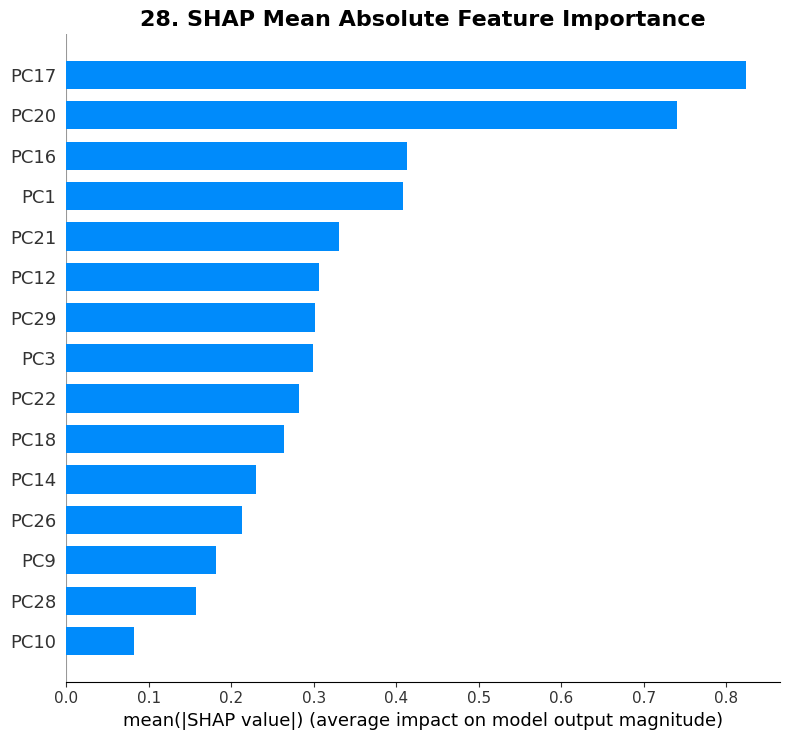

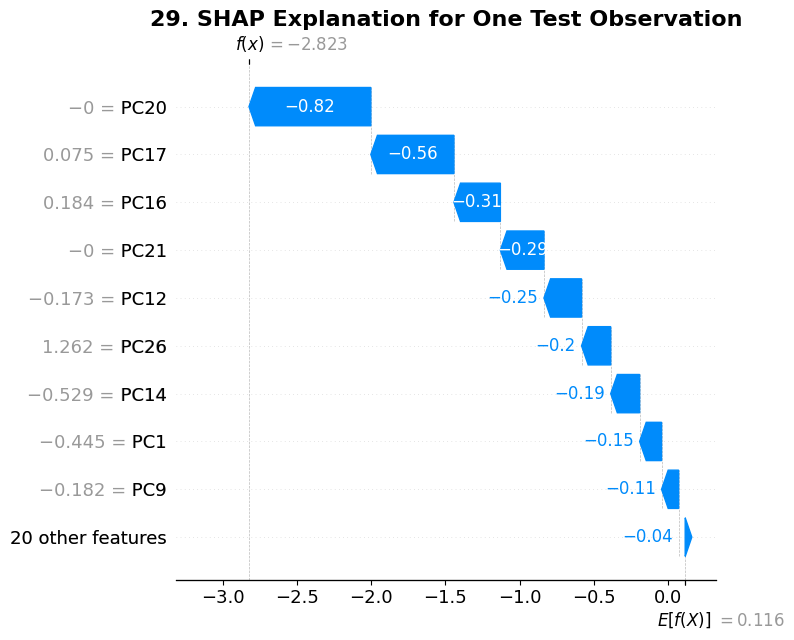

In [ ]:
print("\n🔬 STEP 10: SHAP EXPLAINABILITY")
print("-" * 65)

try:
    import shap

    shap_explainer = shap.TreeExplainer(xgb_model)
    shap_values = shap_explainer.shap_values(X_test_pca)

    shap_feature_names = [f"PC{i+1}" for i in range(X_test_pca.shape[1])]

    shap.summary_plot(
        shap_values,
        X_test_pca,
        feature_names=shap_feature_names,
        max_display=15,
        show=False
    )

    plt.title(
        "27. SHAP Summary Plot",
        fontsize=16,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("figure_27_shap_summary.png", dpi=300, bbox_inches="tight")
    plt.show()

    shap.summary_plot(
        shap_values,
        X_test_pca,
        feature_names=shap_feature_names,
        plot_type="bar",
        max_display=15,
        show=False
    )

    plt.title(
        "28. SHAP Mean Absolute Feature Importance",
        fontsize=16,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("figure_28_shap_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

    if len(X_test_pca) > 0:
        shap_explanation = shap.Explanation(
            values=shap_values[0],
            base_values=shap_explainer.expected_value,
            data=X_test_pca[0],
            feature_names=shap_feature_names
        )

        shap.plots.waterfall(
            shap_explanation,
            max_display=10,
            show=False
        )

        plt.title(
            "29. SHAP Explanation for One Test Observation",
            fontsize=16,
            fontweight="bold"
        )
        plt.tight_layout()
        plt.savefig("figure_29_shap_waterfall.png", dpi=300, bbox_inches="tight")
        plt.show()

except Exception as exc:
    print("⚠️ SHAP analysis could not be completed:")
    print(exc)

In [ ]:
try:
    from lime.lime_tabular import LimeTabularExplainer

    # LIME operates in the PCA feature space used by the XGBoost model.
    lime_explainer = LimeTabularExplainer(
        training_data=X_train_pca,
        feature_names=[f"PC{i+1}" for i in range(X_train_pca.shape[1])],
        class_names=["Negative", "Positive"],
        mode="classification",
        random_state=RANDOM_STATE
    )

    if len(X_test_pca) > 0:
        lime_exp = lime_explainer.explain_instance(
            X_test_pca[0],
            xgb_model.predict_proba,
            num_features=min(10, X_test_pca.shape[1])
        )

        print("\n🔬 LIME explanation for first test observation:")
        for feature, weight in lime_exp.as_list():
            print(f"{feature}: {weight:.4f}")

        lime_exp.save_to_file("lime_explanation_test_sample.html")
        print("✅ Saved: lime_explanation_test_sample.html")

except Exception as exc:
    print("⚠️ LIME analysis could not be completed:")
    print(exc)


🔬 LIME explanation for first test observation:
PC17 > 0.05: -0.1019
PC20 <= -0.00: -0.0892
PC21 <= -0.00: -0.0496
-0.01 < PC16 <= 0.26: -0.0463
-0.45 < PC1 <= -0.19: -0.0334
-0.73 < PC3 <= -0.18: 0.0292
PC28 <= -0.29: -0.0275
PC18 <= -0.11: -0.0273
PC26 > 0.38: -0.0221
PC22 > 0.00: 0.0193
✅ Saved: lime_explanation_test_sample.html


In [ ]:
manuscript_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity (Recall)",
        "Specificity",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Balanced Accuracy",
        "MCC"
    ],
    "Default Threshold (0.50)": [
        default_metrics["Accuracy"],
        default_metrics["Precision"],
        default_metrics["Sensitivity"],
        default_metrics["Specificity"],
        default_metrics["F1-Score"],
        default_metrics["ROC-AUC"],
        default_metrics["PR-AUC"],
        default_metrics["Balanced Accuracy"],
        default_metrics["MCC"]
    ],
    "Sensitivity-Oriented Threshold": [
        tuned_metrics["Accuracy"],
        tuned_metrics["Precision"],
        tuned_metrics["Sensitivity"],
        tuned_metrics["Specificity"],
        tuned_metrics["F1-Score"],
        tuned_metrics["ROC-AUC"],
        tuned_metrics["PR-AUC"],
        tuned_metrics["Balanced Accuracy"],
        tuned_metrics["MCC"]
    ]
})

print("\n📋 MANUSCRIPT-READY RESULTS TABLE")
print("=" * 80)
print(manuscript_results.round(4).to_string(index=False))

manuscript_results.to_csv(
    os.path.join(results_dir, "manuscript_results_table.csv"),
    index=False
)

print(f"\n✅ Saved to {results_dir}/manuscript_results_table.csv")


📋 MANUSCRIPT-READY RESULTS TABLE
              Metric  Default Threshold (0.50)  Sensitivity-Oriented Threshold
            Accuracy                    0.8372                          0.8605
           Precision                    0.9429                          0.9444
Sensitivity (Recall)                    0.8684                          0.8947
         Specificity                    0.6000                          0.6000
            F1-Score                    0.9041                          0.9189
             ROC-AUC                    0.8605                          0.8605
              PR-AUC                    0.9786                          0.9786
   Balanced Accuracy                    0.7342                          0.7474
                 MCC                    0.3859                          0.4296

✅ Saved to reviewer2_results/manuscript_results_table.csv


In [ ]:
print("\n")
print("=" * 80)
print("🏥 FINAL REVISED MONKEYPOX DETECTION EXPERIMENT")
print("=" * 80)

print("\nDATASET")
print(f"Total samples          : {len(df)}")
print(f"Monkeypox positive     : {(y == 1).sum()}")
print(f"Monkeypox negative     : {(y == 0).sum()}")
print(f"Predictor features     : {X.shape[1]}")

print("\nPIPELINE")
print("80:20 stratified split")
print("→ training-only imputation")
print("→ training-only scaling")
print("→ training-only PCA (95% variance)")
print("→ RandomOverSampler on training data")
print("→ XGBoost")
print("→ training-only OOF threshold selection")
print("→ untouched independent test evaluation")

print("\nMODEL")
print("XGBoost: 100 estimators, depth=6, lr=0.1, subsample=0.8, colsample=0.8")

print("\nSELECTED OPERATING POINT")
print(f"Threshold             : {selected_threshold:.2f}")
print(f"Target sensitivity    : {TARGET_SENSITIVITY:.2f}")

print("\nFINAL TEST RESULTS")
for key in [
    "Accuracy", "Precision", "Sensitivity", "Specificity",
    "F1-Score", "ROC-AUC", "PR-AUC", "Balanced Accuracy", "MCC"
]:
    print(f"{key:22s}: {final_metrics[key]:.4f}")

print("\nCONFUSION MATRIX")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

print("\nVALIDATION")
print(f"Repeated stratified CV: {CV_FOLDS}-fold × {CV_REPEATS} repeats")
print(f"Bootstrap repetitions : {N_BOOTSTRAP}")

print("\nOUTPUTS")
print(f"Result directory      : {results_dir}/")
print("Figures saved as figure_*.png")
print("=" * 80)
print("✅ NOTEBOOK COMPLETE")



🏥 FINAL REVISED MONKEYPOX DETECTION EXPERIMENT

DATASET
Total samples          : 211
Monkeypox positive     : 186
Monkeypox negative     : 25
Predictor features     : 46

PIPELINE
80:20 stratified split
→ training-only imputation
→ training-only scaling
→ training-only PCA (95% variance)
→ RandomOverSampler on training data
→ XGBoost
→ training-only OOF threshold selection
→ untouched independent test evaluation

MODEL
XGBoost: 100 estimators, depth=6, lr=0.1, subsample=0.8, colsample=0.8

SELECTED OPERATING POINT
Threshold             : 0.25
Target sensitivity    : 0.90

FINAL TEST RESULTS
Accuracy              : 0.8605
Precision             : 0.9444
Sensitivity           : 0.8947
Specificity           : 0.6000
F1-Score              : 0.9189
ROC-AUC               : 0.8605
PR-AUC                : 0.9786
Balanced Accuracy     : 0.7474
MCC                   : 0.4296

CONFUSION MATRIX
TN=3, FP=2, FN=4, TP=34

VALIDATION
Repeated stratified CV: 5-fold × 10 repeats
Bootstrap repetitions :